

---

## Part 1 — Problem Framing

# Section 1 — Problem Framing

This notebook uses an **explanatory** approach to answer: which content characteristics, platform choices, and timing factors are most strongly associated with a social media post generating a donation? The audience is the communications team and fundraising director.

**Why explanatory?**
The team does not just want to know which past posts converted — they want to know *why*, so they can make better content decisions for future posts. An explanatory model with interpretable odds ratios (logistic, for conversion probability) and coefficients (OLS, for donation value conditional on conversion) gives actionable content strategy guidance.

**Two modelling targets:**
1. Logistic regression: did this post generate any donation? (conversion)
2. OLS: given that a post converted, what was the donation value?

**Who cares?**
- The social media manager, who decides what to post and when
- The fundraising director, who sets content strategy and boost budget
- The digital analyst, who tracks campaign ROI

# Campaign & Social Media ROI Optimization
## CRISP-DM Explanatory Analysis Pipeline

---

### Business Context

The first two donor pipelines focus on **people** — who joins, who stays, who leaves.
This pipeline focuses on **content** — what the organization puts out into the world
and how that content translates into donations and engagement.

The unit of observation is a **social media post**, not a person.

Every time the organization publishes a post on Facebook, Instagram, TikTok,
LinkedIn, YouTube, WhatsApp, or Twitter, they are making an implicit bet — that
this combination of content type, platform, tone, media format, hashtags, timing,
and message will resonate enough to drive **actual donations**, not just likes
and shares.

> **This pipeline replaces intuition with statistical evidence** drawn from the
> organization's own data. It answers: looking backward at every post this
> organization has published, which characteristics are statistically associated
> with higher donation referrals, higher engagement rates, and higher estimated
> donation value?

### Critical Distinction: Donations, Not Vanity Metrics

The target variables in this pipeline are **donation referrals and estimated
donation value**, NOT engagement rate or reach. Engagement metrics appear as
**features** (inputs), not outcomes.

- A post that goes viral with 10,000 likes may generate zero donations.
- A quiet, targeted post may generate significant giving.
- The organization's goal is to **fund safehouses**, not accumulate social media followers.

### Two-Part (Hurdle) Model Approach

Many posts generate zero donations. The rigorous approach is a **two-part model**:

1. **Part A (Logistic Regression):** What makes a post generate *any* donations at
   all? (binary: converted vs. not)
2. **Part B (OLS Regression):** Among posts that *did* convert, what drives the
   donation *value*? (continuous: log PHP)

This correctly separates two distinct processes and avoids conflating them.

> **This is an EXPLANATORY model — not predictive.** No train/test splits. The
> goal is coefficient interpretation and actionable content-strategy guidance.

---
## Section 1 — Configuration Block (Single Source of Truth)

A single `CONFIG` dictionary centralizes every configurable parameter.
All subsequent cells reference `CONFIG` — no hard-coded paths, column names,
thresholds, or magic numbers anywhere else.

In [1]:
import os

CONFIG = {
    # 'csv_dir': 'lighthouse_csv_v7/',
    'csv_dir': 'newData/',
    'sql_connection_string': os.environ['DATABASE_URL'],
    'use_sql': True,
    'table_names': {
        'social_media_posts': 'social_media_posts.csv',
        'donations': 'donations.csv',
        'donation_allocations': 'donation_allocations.csv',
        'public_impact_snapshots': 'public_impact_snapshots.csv'
    },
    'base_output': 'output/',
    'output_dir': '../output/social-media-explanatory',
    'figures_dir': '../output/social-media-explanatory',
    'models_dir': '../output/social-media-explanatory',
    'json_dir': '../output/social-media-explanatory',
    'vif_threshold': 10,
    'significance_level': 0.05,
    'loose_significance_level': 0.10,
    'dpi': 150,
    'random_state': 42,
    'rolling_window_days': 30,
    'target_primary': 'log_estimated_donation_value_php',
    'target_binary': 'has_any_donations',
    'platforms': [
        'Facebook', 'Instagram', 'Twitter', 'TikTok',
        'LinkedIn', 'YouTube', 'WhatsApp'
    ],
    'post_types': [
        'ImpactStory', 'Campaign', 'EventPromotion',
        'ThankYou', 'EducationalContent', 'FundraisingAppeal'
    ],
    'sentiment_tones': [
        'Hopeful', 'Urgent', 'Celebratory',
        'Informative', 'Grateful', 'Emotional'
    ],
    'media_types': ['Photo', 'Video', 'Carousel', 'Text', 'Reel'],
    'cta_types': ['DonateNow', 'LearnMore', 'ShareStory', 'SignUp']
}

---
## Section 2 — Import All Libraries

All libraries needed for the EXPLANATORY pipeline.
No `train_test_split` or cross-validation utilities are imported.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_breusch_godfrey
from statsmodels.stats.stattools import durbin_watson
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import jarque_bera, shapiro, probplot
from scipy import stats as sp_stats
import os
import json
import pickle
import warnings
import datetime

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = CONFIG['dpi']
sns.set_style('whitegrid')

for d in [CONFIG['output_dir'], CONFIG['figures_dir'],
          CONFIG['models_dir'], CONFIG['json_dir']]:
    os.makedirs(d, exist_ok=True)



---

## Part 2 — Data Acquisition, Preparation & Exploration

# Section 2 — Data Acquisition, Preparation & Exploration

This section loads post and donation data, validates the post-to-donation linkage, engineers content features (platform, post type, media type, engagement metrics, timing), performs univariate and bivariate EDA, and prepares the clean modelling DataFrame. The engagement-metric caveat (post-publication engagement is a potential leakage source) is documented and addressed.

---
## Section 3 — Data Loading and Schema Validation

Two helper functions handle loading and validation:

| Function | Purpose |
|---|---|
| `load_table(table_key)` | Loads from CSV or SQL based on `CONFIG['use_sql']` |
| `validate_schema(df, table_key)` | Checks that expected columns exist |

**Source tables:**

| Table | Role |
|---|---|
| `social_media_posts` | Spine — one row per post |
| `donations` | Linked via `referral_post_id` |
| `donation_allocations` | Where the money went |
| `public_impact_snapshots` | Monthly impact communications |

In [3]:
def load_table(table_key):
    """Load a table from CSV (or SQL when CONFIG['use_sql'] is True)."""
    if CONFIG['use_sql']:
        import sqlalchemy
        engine = sqlalchemy.create_engine(CONFIG['sql_connection_string'])
        # Strip .csv suffix if present — use table name not filename
        table_name = CONFIG['table_names'][table_key].replace('.csv', '')
        df = pd.read_sql_table(table_name, engine)
        # Strip tz-awareness from all datetime columns (PostgreSQL returns UTC-aware)
        for _col in df.select_dtypes(include=['datetimetz']).columns:
            df[_col] = df[_col].dt.tz_localize(None)
    else:
        file_path = os.path.join(CONFIG['csv_dir'], CONFIG['table_names'][table_key])
        df = pd.read_csv(file_path)
    print(f"Loaded {table_key}: {df.shape[0]:,} rows × {df.shape[1]} columns")
    return df


def validate_schema(df, table_key):
    """Warn (but don't crash) if expected columns are missing."""
    expected = {
        'social_media_posts': [
            'post_id', 'platform', 'platform_post_id', 'post_url',
            'created_at', 'day_of_week', 'post_hour', 'post_type',
            'media_type', 'caption', 'hashtags', 'num_hashtags',
            'mentions_count', 'has_call_to_action', 'call_to_action_type',
            'content_topic', 'sentiment_tone', 'caption_length',
            'features_resident_story', 'campaign_name', 'is_boosted',
            'boost_budget_php', 'impressions', 'reach', 'likes',
            'comments', 'shares', 'saves', 'click_throughs',
            'video_views', 'engagement_rate', 'profile_visits',
            'donation_referrals', 'estimated_donation_value_php',
            'follower_count_at_post', 'watch_time_seconds',
            'avg_view_duration_seconds', 'subscriber_count_at_post',
            'forwards'
        ],
        'donations': [
            'donation_id', 'supporter_id', 'donation_type',
            'donation_date', 'is_recurring', 'campaign_name',
            'channel_source', 'currency_code', 'amount',
            'estimated_value', 'impact_unit', 'notes',
            'referral_post_id'
        ],
        'donation_allocations': [
            'allocation_id', 'donation_id', 'safehouse_id',
            'program_area', 'amount_allocated', 'allocation_date',
            'allocation_notes'
        ],
        'public_impact_snapshots': [
            'snapshot_id', 'snapshot_date', 'headline',
            'summary_text', 'metric_payload_json', 'is_published',
            'published_at'
        ]
    }
    if table_key not in expected:
        print(f"  ⚠  No schema defined for '{table_key}'")
        return
    missing = [c for c in expected[table_key] if c not in df.columns]
    if missing:
        print(f"  ⚠  Missing columns in {table_key}: {missing}")
    else:
        print(f"  ✓  Schema validation passed for {table_key}")

### Load and Inspect All Tables

In [4]:
posts_raw = load_table('social_media_posts')
validate_schema(posts_raw, 'social_media_posts')

donations_raw = load_table('donations')
validate_schema(donations_raw, 'donations')

allocations_raw = load_table('donation_allocations')
validate_schema(allocations_raw, 'donation_allocations')

snapshots_raw = load_table('public_impact_snapshots')
validate_schema(snapshots_raw, 'public_impact_snapshots')

df_raw_master = posts_raw.copy()

print("\n" + "=" * 60)
print("QUICK DATA PROFILE")
print("=" * 60)
for name, df in [('posts', posts_raw), ('donations', donations_raw),
                 ('allocations', allocations_raw), ('snapshots', snapshots_raw)]:
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    print(f"\n{name}  ({df.shape[0]:,} × {df.shape[1]})")
    if len(miss):
        print(f"  Missing: {dict(miss)}")
    else:
        print("  No missing values")

sm_donations = donations_raw[
    (donations_raw['channel_source'] == 'SocialMedia') &
    donations_raw['referral_post_id'].notna()
]
print(f"\nDonations with social-media referral: {len(sm_donations)} / {len(donations_raw)}")

Loaded social_media_posts: 812 rows × 39 columns
  ✓  Schema validation passed for social_media_posts
Loaded donations: 424 rows × 13 columns
  ✓  Schema validation passed for donations


Loaded donation_allocations: 523 rows × 7 columns
  ✓  Schema validation passed for donation_allocations
Loaded public_impact_snapshots: 50 rows × 7 columns
  ✓  Schema validation passed for public_impact_snapshots

QUICK DATA PROFILE

posts  (812 × 39)
  Missing: {'hashtags': np.int64(148), 'call_to_action_type': np.int64(319), 'campaign_name': np.int64(580), 'boost_budget_php': np.int64(685), 'video_views': np.int64(479), 'watch_time_seconds': np.int64(741), 'avg_view_duration_seconds': np.int64(741), 'subscriber_count_at_post': np.int64(741), 'forwards': np.int64(719)}

donations  (424 × 13)
  Missing: {'campaign_name': np.int64(279), 'currency_code': np.int64(188), 'amount': np.int64(188), 'notes': np.int64(1), 'referral_post_id': np.int64(347)}

allocations  (523 × 7)
  Missing: {'allocation_notes': np.int64(521)}

snapshots  (50 × 7)
  No missing values

Donations with social-media referral: 77 / 424


---
## Section 5 — Univariate Exploratory Data Analysis

Profile every column in each table, then visualize the most important
distributions and check for zero-inflation in the donation target.

posts: numeric=23, categorical=12
donations: numeric=5, categorical=6
allocations: numeric=4, categorical=2
snapshots: numeric=1, categorical=3

--- Zero-Inflation Analysis ---
Posts with zero donations: 290/812 (35.7%)
Mean donation referrals per post: 12.80
Max: 458


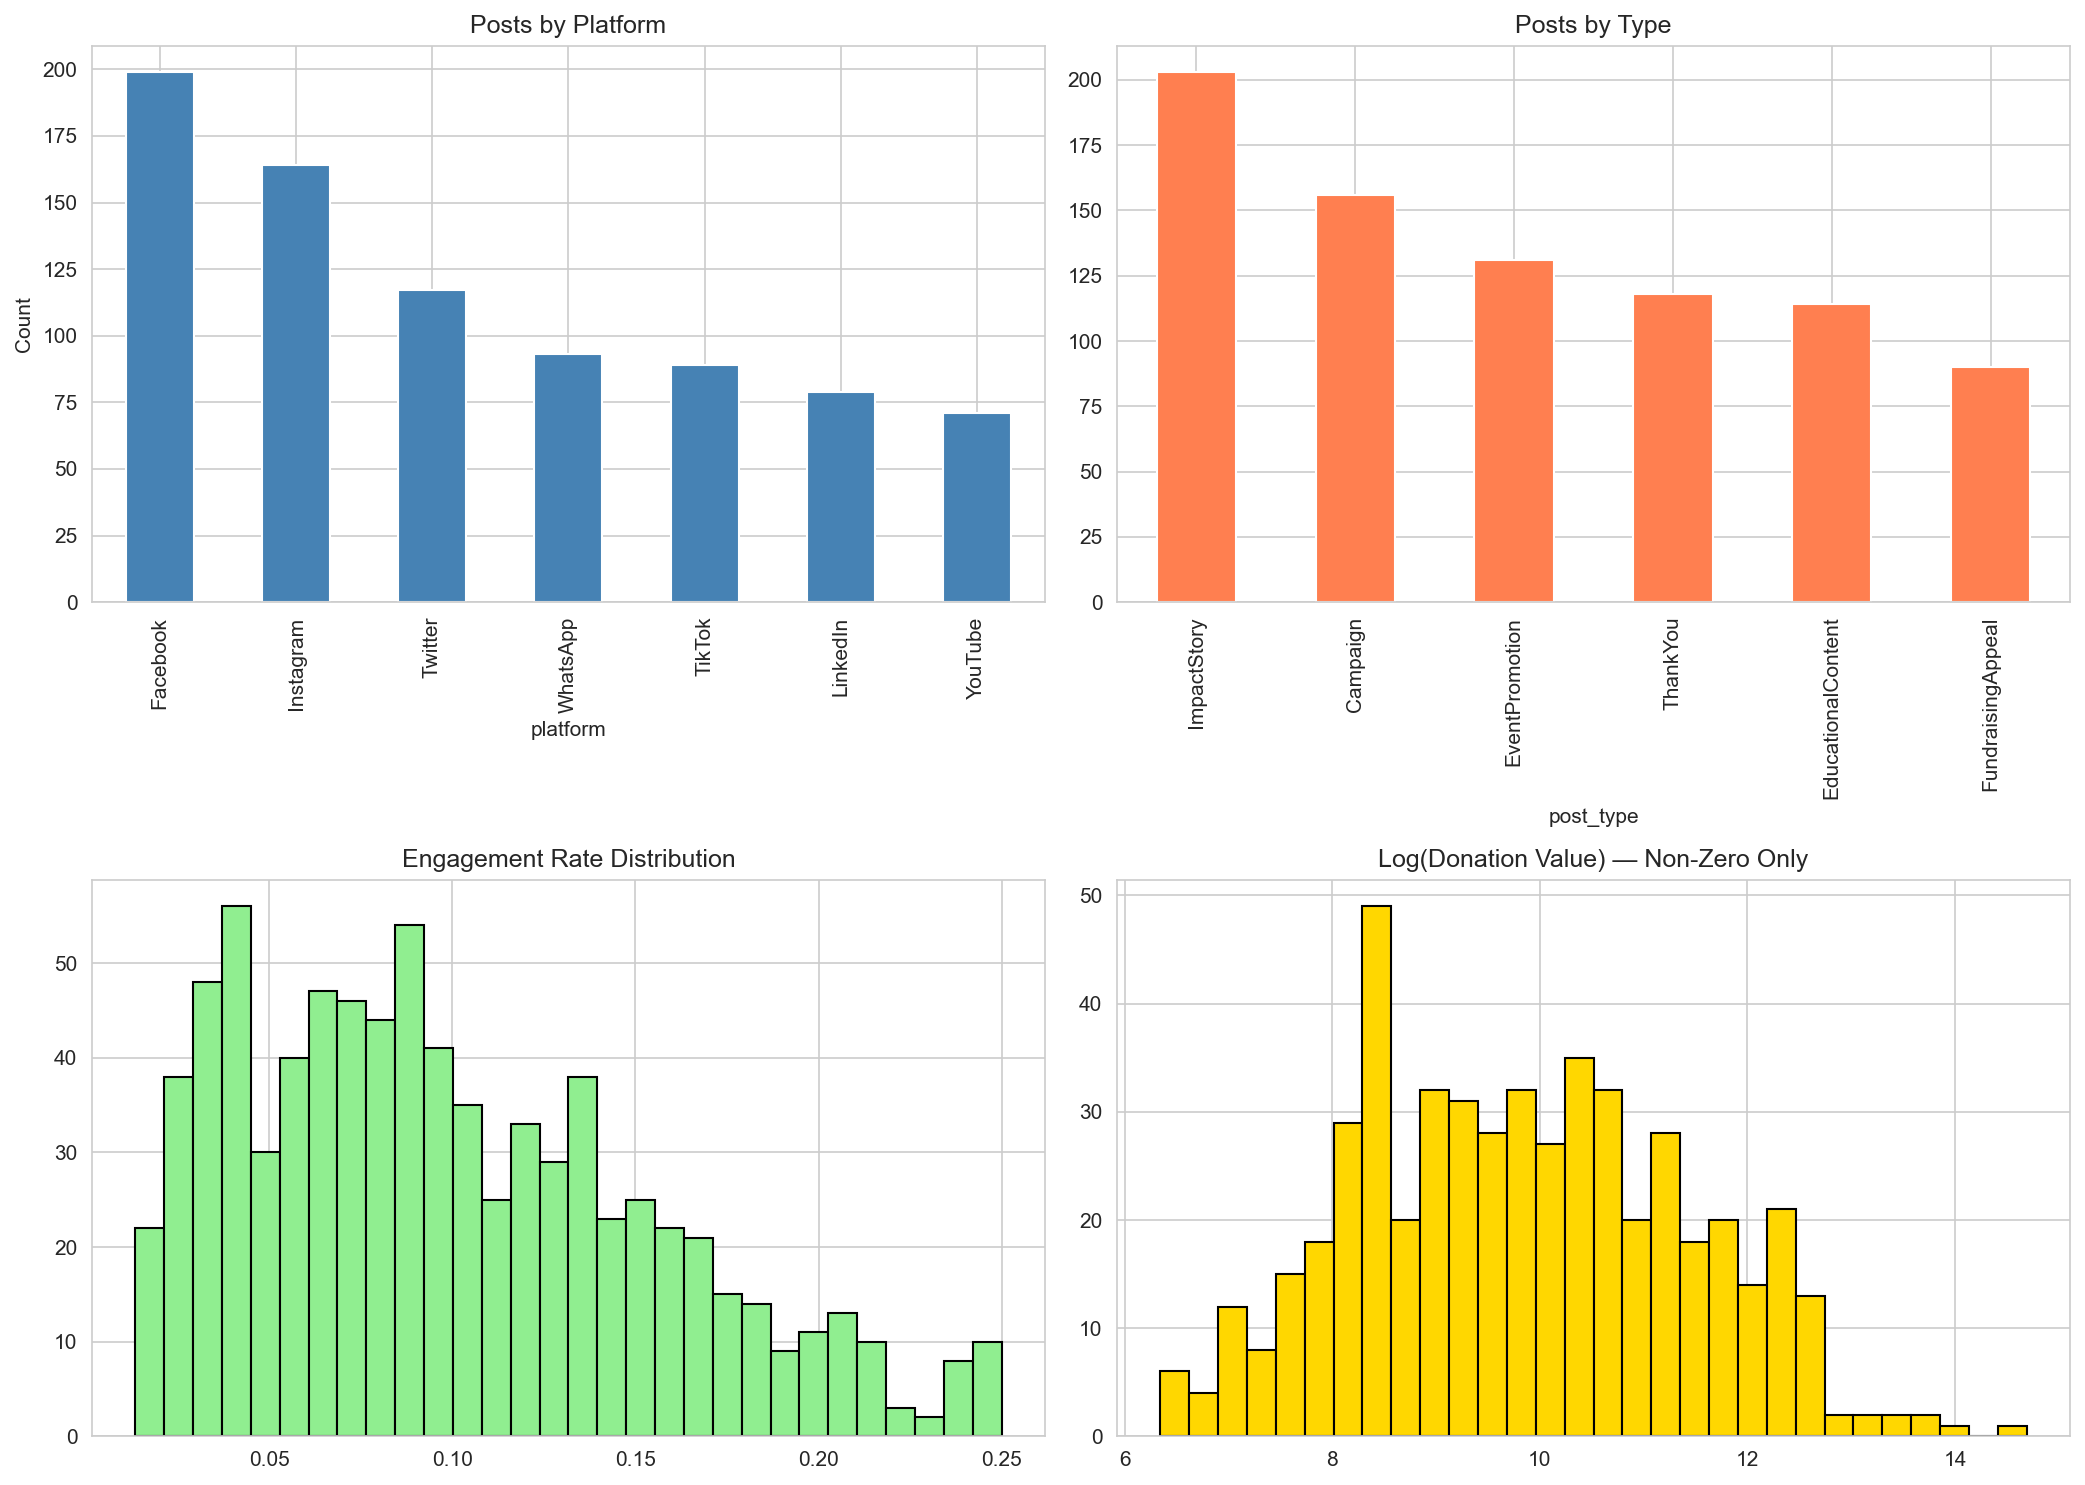

In [5]:
def univariate_profile(df, table_name):
    """Return a dict summarizing numeric and categorical columns."""
    findings = {
        'table_name': table_name,
        'shape': df.shape,
        'numeric': {},
        'categorical': {}
    }
    for col in df.select_dtypes(include=[np.number]).columns:
        s = df[col].dropna()
        findings['numeric'][col] = {
            'mean': round(float(s.mean()), 3) if len(s) else None,
            'median': round(float(s.median()), 3) if len(s) else None,
            'std': round(float(s.std()), 3) if len(s) else None,
            'skew': round(float(sp_stats.skew(s)), 3) if len(s) else None,
            'pct_missing': round(df[col].isna().mean() * 100, 1)
        }
    for col in df.select_dtypes(include=['object']).columns:
        findings['categorical'][col] = {
            'unique': int(df[col].nunique()),
            'top_5': df[col].value_counts().head(5).to_dict(),
            'pct_missing': round(df[col].isna().mean() * 100, 1)
        }
    return findings


EDA_FINDINGS = {}
for name, df in [('posts', posts_raw), ('donations', donations_raw),
                 ('allocations', allocations_raw), ('snapshots', snapshots_raw)]:
    f = univariate_profile(df, name)
    EDA_FINDINGS[name] = f
    print(f"{name}: numeric={len(f['numeric'])}, categorical={len(f['categorical'])}")

print("\n--- Zero-Inflation Analysis ---")
zero_posts = (posts_raw['donation_referrals'] == 0).sum()
total_posts = len(posts_raw)
print(f"Posts with zero donations: {zero_posts}/{total_posts} "
      f"({100 * zero_posts / total_posts:.1f}%)")
print(f"Mean donation referrals per post: {posts_raw['donation_referrals'].mean():.2f}")
print(f"Max: {posts_raw['donation_referrals'].max()}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

posts_raw['platform'].value_counts().plot(
    kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Posts by Platform')
axes[0, 0].set_ylabel('Count')

posts_raw['post_type'].value_counts().plot(
    kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Posts by Type')

posts_raw['engagement_rate'].hist(
    bins=30, ax=axes[1, 0], color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Engagement Rate Distribution')

nz = posts_raw.loc[
    posts_raw['estimated_donation_value_php'] > 0,
    'estimated_donation_value_php'
]
axes[1, 1].hist(np.log1p(nz), bins=30, color='gold', edgecolor='black')
axes[1, 1].set_title('Log(Donation Value) — Non-Zero Only')

plt.tight_layout()
plt.savefig(CONFIG['figures_dir'] + 'univariate_eda.png',
            dpi=CONFIG['dpi'], bbox_inches='tight')
plt.show()

---
## Section 6 — Validate Post-to-Donation Linkage

Confirm the link between `social_media_posts` and `donations` via
`referral_post_id`.  Compare estimated vs. actual donation value and
examine where social-media-referred donations are allocated.

In [6]:
donations_social = donations_raw[
    (donations_raw['channel_source'] == 'SocialMedia') &
    donations_raw['referral_post_id'].notna()
].copy()

print(f"Social-media donations with post referral: "
      f"{len(donations_social)} / {len(donations_raw)}")

if len(donations_social) > 0:
    merged = donations_social.merge(
        posts_raw[['post_id', 'estimated_donation_value_php',
                   'platform', 'post_type']],
        left_on='referral_post_id', right_on='post_id', how='left'
    )

    agg = merged.groupby('referral_post_id').agg(
        actual_total=('estimated_value', 'sum'),
        post_estimated=('estimated_donation_value_php', 'first')
    ).reset_index()

    corr = agg['actual_total'].corr(agg['post_estimated'])
    print(f"Correlation (estimated vs. actual): {corr:.3f}")

    alloc = merged.merge(
        allocations_raw[['donation_id', 'safehouse_id',
                         'program_area', 'amount_allocated']],
        on='donation_id', how='left'
    )

    print("\nTop safehouses receiving social-media-referred donations:")
    top_sh = (alloc.groupby('safehouse_id')['amount_allocated']
              .sum().sort_values(ascending=False).head(5))
    for sh, amt in top_sh.items():
        print(f"  Safehouse {sh}: ₱{amt:,.0f}")

    print("\nAllocation by program area:")
    top_pa = (alloc.groupby('program_area')['amount_allocated']
              .sum().sort_values(ascending=False))
    for pa, amt in top_pa.items():
        print(f"  {pa}: ₱{amt:,.0f}")
else:
    print("No social-media donations with post referrals found.")

Social-media donations with post referral: 77 / 424
Correlation (estimated vs. actual): -0.047

Top safehouses receiving social-media-referred donations:
  Safehouse 8: ₱8,624
  Safehouse 2: ₱7,588
  Safehouse 5: ₱7,379
  Safehouse 4: ₱6,071
  Safehouse 7: ₱5,568

Allocation by program area:
  Wellbeing: ₱11,318
  Education: ₱11,151
  Operations: ₱10,391
  Transport: ₱9,719
  Maintenance: ₱4,896
  Outreach: ₱4,833


---
## Section 7 — Define and Engineer Target Variables

| Target | Type | Population | Model |
|---|---|---|---|
| `has_any_donations` | Binary 0/1 | All posts | Part A — Logistic |
| `log_estimated_donation_value_php` | Continuous (log ₱) | Converters only | Part B — OLS |

The **two-part hurdle model** correctly separates:
1. What makes a post convert *anyone* at all, and
2. Among converters, what drives donation *value*.

In [7]:
posts_raw['has_any_donations'] = (
    posts_raw['donation_referrals'] > 0
).astype(int)

posts_raw['log_estimated_donation_value_php'] = np.log1p(
    posts_raw['estimated_donation_value_php']
)

part_a_n = len(posts_raw)
n_convert = posts_raw['has_any_donations'].sum()
n_zero = part_a_n - n_convert

print("=" * 60)
print("TARGET VARIABLE SUMMARY")
print("=" * 60)
print(f"\nPart A (Logistic) — All Posts: n = {part_a_n:,}")
print(f"  Class 0 (no donations): {n_zero:,}  ({100 * n_zero / part_a_n:.1f}%)")
print(f"  Class 1 (has donations): {n_convert:,}  ({100 * n_convert / part_a_n:.1f}%)")

converters = posts_raw[posts_raw['donation_referrals'] > 0].copy()
part_b_n = len(converters)
print(f"\nPart B (OLS) — Converters Only: n = {part_b_n:,}  "
      f"({100 * part_b_n / part_a_n:.1f}% of all posts)")
print(f"  Donation value (PHP): "
      f"mean = {np.expm1(converters['log_estimated_donation_value_php'].mean()):,.0f}, "
      f"median = {np.expm1(converters['log_estimated_donation_value_php'].median()):,.0f}")

TARGET VARIABLE SUMMARY

Part A (Logistic) — All Posts: n = 812
  Class 0 (no donations): 290  (35.7%)
  Class 1 (has donations): 522  (64.3%)

Part B (OLS) — Converters Only: n = 522  (64.3% of all posts)
  Donation value (PHP): mean = 18,252, median = 17,113


---
## Section 8 — Feature Engineering: Post Characteristics

One-hot encode the core categorical variables and create numeric features
from each post's intrinsic attributes.

| Feature Group | Source Column | Method |
|---|---|---|
| Post type | `post_type` | One-hot (drop first) |
| Platform | `platform` | One-hot (drop first) |
| Media type | `media_type` | One-hot |
| Sentiment tone | `sentiment_tone` | One-hot |
| CTA type | `call_to_action_type` | One-hot + `has_cta` binary |
| Content topic | `content_topic` | One-hot |
| Caption length | `caption_length` | Numeric |
| Hashtag count | `num_hashtags` | Numeric |
| Resident story | `features_resident_story` | Binary |
| Weekend flag | `day_of_week` | Binary |

In [8]:
df_features = posts_raw[['post_id']].copy()

df_features['hashtag_count'] = posts_raw['num_hashtags']
df_features['has_cta'] = posts_raw['has_call_to_action'].astype(int)
df_features['caption_length'] = posts_raw['caption_length']
df_features['is_weekend'] = posts_raw['day_of_week'].isin(
    ['Saturday', 'Sunday']
).astype(int)
df_features['features_resident_story'] = (
    posts_raw['features_resident_story'].astype(int)
)

cat_cols = ['platform', 'post_type', 'sentiment_tone',
            'media_type', 'call_to_action_type', 'content_topic']

for col in cat_cols:
    if col in posts_raw.columns:
        dummies = pd.get_dummies(posts_raw[col], prefix=col, drop_first=False)
        df_features = pd.concat([df_features, dummies], axis=1)
        print(f"  One-hot encoded {col}: {dummies.shape[1]} dummies")

print(f"\nTotal post-characteristic features: {df_features.shape[1] - 1}")

  One-hot encoded platform: 7 dummies
  One-hot encoded post_type: 6 dummies
  One-hot encoded sentiment_tone: 6 dummies
  One-hot encoded media_type: 5 dummies
  One-hot encoded call_to_action_type: 4 dummies
  One-hot encoded content_topic: 9 dummies

Total post-characteristic features: 42


---
## Section 9 — Feature Engineering: Platform × Post Type Interactions

A `FundraisingAppeal` on LinkedIn may perform very differently from one on
TikTok.  Interaction terms capture these platform-specific content effects.

Rare combinations (< 5 posts) are dropped to avoid model instability.

In [9]:
combo_counts = posts_raw.groupby(['platform', 'post_type']).size()
print(f"Total platform × post_type combos: {len(combo_counts)}")

df_interactions = posts_raw[['post_id']].copy()
dropped = []

for (plat, ptype), n in combo_counts.items():
    col = f"inter_{plat}_{ptype}".replace(' ', '_')
    if n >= 5:
        df_interactions[col] = (
            (posts_raw['platform'] == plat) &
            (posts_raw['post_type'] == ptype)
        ).astype(int)
    else:
        dropped.append((plat, ptype, n))

print(f"Kept interactions: {df_interactions.shape[1] - 1}")
if dropped:
    print("Dropped (< 5 posts):")
    for p, t, n in dropped:
        print(f"  {p} × {t}  (n={n})")

Total platform × post_type combos: 42
Kept interactions: 41
Dropped (< 5 posts):
  LinkedIn × FundraisingAppeal  (n=2)


---
## Section 10 — Feature Engineering: Temporal Context

Extract timing features from `created_at` to capture when a post was
published.  Month is an important confounder — giving spikes around
Christmas, end-of-year, and local holidays.

In [10]:
posts_raw['created_at_dt'] = pd.to_datetime(posts_raw['created_at'])

df_temporal = posts_raw[['post_id']].copy()
df_temporal['post_hour'] = posts_raw['post_hour']

dow_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
           'Friday': 4, 'Saturday': 5, 'Sunday': 6}
df_temporal['day_of_week_numeric'] = posts_raw['day_of_week'].map(dow_map)
df_temporal['month'] = posts_raw['created_at_dt'].dt.month
df_temporal['quarter'] = posts_raw['created_at_dt'].dt.quarter
df_temporal['is_peak_hour'] = posts_raw['post_hour'].isin(
    [9, 10, 11, 12, 18, 19, 20]
).astype(int)
df_temporal['days_since_first_post'] = (
    posts_raw['created_at_dt'] - posts_raw['created_at_dt'].min()
).dt.days

date_min = posts_raw['created_at_dt'].min().date()
date_max = posts_raw['created_at_dt'].max().date()
print(f"Date range: {date_min} → {date_max}")
print(f"Peak-hour posts: {df_temporal['is_peak_hour'].sum()} / {len(df_temporal)}")

Date range: 2023-01-05 → 2026-02-26
Peak-hour posts: 330 / 812


---
## Section 11 — Feature Engineering: Rolling Organizational Context

For each post, compute contextual features from the **preceding 30-day window**.

| Feature | Purpose |
|---|---|
| `rolling_avg_ref_30d` | Average donation referrals/post in prior 30 days |
| `rolling_avg_val_30d` | Average donation value/post in prior 30 days |
| `rolling_post_count_30d` | Post volume/frequency |
| `is_during_active` | Whether the rolling average is above the median |

> **Why this matters:** Without organizational-momentum controls the model
> will confuse calendar effects and campaign momentum with content effects.

In [11]:
window_days = CONFIG['rolling_window_days']

df_sort = posts_raw[['post_id', 'created_at_dt',
                     'donation_referrals',
                     'estimated_donation_value_php']].copy()
df_sort = df_sort.sort_values('created_at_dt').reset_index(drop=True)

median_val = df_sort['estimated_donation_value_php'].median()

roll_ref = np.zeros(len(df_sort))
roll_val = np.zeros(len(df_sort))
roll_cnt = np.zeros(len(df_sort))
roll_act = np.zeros(len(df_sort), dtype=int)

for i in range(len(df_sort)):
    curr = df_sort.loc[i, 'created_at_dt']
    start = curr - pd.Timedelta(days=window_days)
    mask = (df_sort['created_at_dt'] >= start) & (df_sort['created_at_dt'] < curr)
    w = df_sort.loc[mask]
    if len(w):
        roll_ref[i] = w['donation_referrals'].mean()
        roll_val[i] = w['estimated_donation_value_php'].mean()
        roll_cnt[i] = len(w)
        if roll_val[i] > median_val:
            roll_act[i] = 1

df_rolling = pd.DataFrame({
    'post_id': df_sort['post_id'].values,
    'rolling_avg_ref_30d': roll_ref,
    'rolling_avg_val_30d': roll_val,
    'rolling_post_count_30d': roll_cnt,
    'is_during_active': roll_act
})

print(f"Rolling {window_days}-day features built.  "
      f"Posts with prior history: {(roll_cnt > 0).sum()}")

Rolling 30-day features built.  Posts with prior history: 811


---
## Section 12 — Feature Engineering: Engagement Metrics (with Caveat)

> ⚠️ **REVERSE CAUSALITY WARNING**
>
> Engagement metrics (likes, shares, reach) are *outcomes* of the same post,
> not causes of donations.  Including them creates a circular argument.
> The model is NOT saying "more likes cause more donations."
>
> We keep only **`reach`** (exposure) and **`click_throughs`** (intent) as
> engagement controls.  This avoids severe multicollinearity among the
> individual engagement metrics (likes ↔ comments ↔ shares ↔ impressions).

In [12]:
df_engagement = posts_raw[['post_id']].copy()
df_engagement['log_reach'] = np.log1p(posts_raw['reach'])
df_engagement['log_click_throughs'] = np.log1p(posts_raw['click_throughs'])

print("Engagement features INCLUDED: log_reach, log_click_throughs")
print("Engagement features EXCLUDED (reverse causality):")
print("  likes, comments, shares, saves, impressions, engagement_rate")

Engagement features INCLUDED: log_reach, log_click_throughs
Engagement features EXCLUDED (reverse causality):
  likes, comments, shares, saves, impressions, engagement_rate


---
## Section 13 — Feature Engineering: Boost Efficiency

| Feature | Definition |
|---|---|
| `log_boost_budget` | `log1p(boost_budget_php)` — handles diminishing returns |
| `donation_value_per_boost` | ROAS = donation value / boost budget |

> ⚠️ **Selection bias:** The organization does NOT boost posts randomly.
> They boost posts they believe will perform well.  Better performance of
> boosted posts may reflect intrinsic quality, not the boost itself.

In [13]:
df_boost = posts_raw[['post_id']].copy()
df_boost['log_boost_budget'] = np.log1p(
    posts_raw['boost_budget_php'].fillna(0)
)
df_boost['donation_value_per_boost'] = np.where(
    posts_raw['boost_budget_php'] > 0,
    posts_raw['estimated_donation_value_php'] / posts_raw['boost_budget_php'],
    np.nan
)

n_boosted = (posts_raw['is_boosted'] == True).sum()
print(f"Boosted posts: {n_boosted} / {len(posts_raw)}")
print(f"Avg ROAS (boosted only): "
      f"{df_boost['donation_value_per_boost'].mean():.2f}")

Boosted posts: 127 / 812
Avg ROAS (boosted only): 39.80


---
## Section 14 — Feature Engineering: Public Impact Snapshot Context

Hypothesis: posts published shortly after an impact snapshot perform better
because the organizational narrative is fresh.

Features engineered by date alignment (not a direct key join):

- `days_since_last_snap` — days since the most recent published snapshot
- `snap_in_same_month` — binary flag

In [14]:
snapshots_raw['snapshot_date_dt'] = pd.to_datetime(snapshots_raw['snapshot_date'])
published = snapshots_raw[snapshots_raw['is_published']].copy()

df_snapshot = posts_raw[['post_id']].copy()
days_arr = np.zeros(len(posts_raw))
same_mo = np.zeros(len(posts_raw), dtype=int)

for i, post_dt in enumerate(posts_raw['created_at_dt']):
    prior = published[published['snapshot_date_dt'] <= post_dt]
    if len(prior):
        last = prior['snapshot_date_dt'].max()
        days_arr[i] = (post_dt - last).days
        if post_dt.year == last.year and post_dt.month == last.month:
            same_mo[i] = 1

df_snapshot['days_since_last_snap'] = days_arr
df_snapshot['snap_in_same_month'] = same_mo

print(f"Published snapshots used: {len(published)}")
print(f"Posts in same month as snapshot: {same_mo.sum()}")

Published snapshots used: 50
Posts in same month as snapshot: 812


---
## Section 15 — Build Clean Modeling DataFrame

Merge all engineered features into a single `df_model` with **one row per
post**.  Handle missing values (median imputation for numeric) and store
`TRAINED_DUMMY_COLUMNS` for deployment alignment.

In [15]:
df_model = posts_raw[[
    'post_id', 'created_at', 'estimated_donation_value_php',
    'donation_referrals', 'engagement_rate', 'has_any_donations',
    'log_estimated_donation_value_php'
]].copy()

feature_dfs = [df_features, df_interactions, df_temporal,
               df_rolling, df_engagement, df_boost, df_snapshot]

for fdf in feature_dfs:
    df_model = df_model.merge(fdf, on='post_id', how='left')
    print(f"  + {fdf.shape[1] - 1} features  →  {df_model.shape[1]} total cols")

for col in df_model.select_dtypes(include=['bool']).columns:
    df_model[col] = df_model[col].astype(int)

imputed = []
for col in df_model.select_dtypes(include=[np.number]).columns:
    n_miss = df_model[col].isna().sum()
    if n_miss > 0:
        df_model[col].fillna(df_model[col].median(), inplace=True)
        imputed.append((col, n_miss))

df_raw_master = posts_raw.copy()
df_raw_master = df_raw_master.merge(
    df_boost[['post_id', 'log_boost_budget']], on='post_id', how='left'
)

TRAINED_DUMMY_COLUMNS = [
    c for c in df_model.columns
    if c not in ['post_id', 'created_at', 'estimated_donation_value_php',
                 'donation_referrals', 'engagement_rate',
                 'has_any_donations', 'log_estimated_donation_value_php']
]

print(f"\nModel DataFrame: {df_model.shape}")
print(f"Remaining missing: {df_model.isna().sum().sum()}")
if imputed:
    print("Imputed columns:")
    for c, n in imputed:
        print(f"  {c}: {n} NaNs → median")

  + 42 features  →  49 total cols
  + 41 features  →  90 total cols
  + 6 features  →  96 total cols
  + 4 features  →  100 total cols
  + 2 features  →  102 total cols
  + 2 features  →  104 total cols
  + 2 features  →  106 total cols

Model DataFrame: (812, 106)
Remaining missing: 0
Imputed columns:
  donation_value_per_boost: 685 NaNs → median


---
## Section 16 — Drop Unused Columns and Document Feature Set

Every drop is justified:

| Column | Reason for Dropping |
|---|---|
| `post_id` | Identifier, not a feature |
| `created_at` | Already used to engineer timing features |
| `engagement_rate` | Composite of excluded metrics |
| Target columns | Must not appear as features |

In [16]:
drop_candidates = [
    'post_id', 'created_at', 'engagement_rate',
    'has_any_donations', 'log_estimated_donation_value_php',
    'estimated_donation_value_php', 'donation_referrals'
]

drop_cols = [c for c in drop_candidates if c in df_model.columns]
df_model_features = df_model.drop(columns=drop_cols)

df_model_features = df_model_features.replace([np.inf, -np.inf], np.nan)
n_dirty = df_model_features.isna().sum().sum()
if n_dirty:
    df_model_features = df_model_features.fillna(df_model_features.median())
    print(f"Cleaned {n_dirty} NaN/inf values (median imputed)")

feature_cols = df_model_features.columns.tolist()
print(f"Dropped: {drop_cols}")
print(f"\nFinal feature count: {len(feature_cols)}")
print(f"First 15: {feature_cols[:15]}")

Dropped: ['post_id', 'created_at', 'engagement_rate', 'has_any_donations', 'log_estimated_donation_value_php', 'estimated_donation_value_php', 'donation_referrals']

Final feature count: 99
First 15: ['hashtag_count', 'has_cta', 'caption_length', 'is_weekend', 'features_resident_story', 'platform_Facebook', 'platform_Instagram', 'platform_LinkedIn', 'platform_TikTok', 'platform_Twitter', 'platform_WhatsApp', 'platform_YouTube', 'post_type_Campaign', 'post_type_EducationalContent', 'post_type_EventPromotion']


---
## Section 17 — Bivariate Exploratory Data Analysis

Explore relationships between features and both targets.

**Key question:** Is the "best" content for engagement the same as the
"best" for donations?  The gap is one of the most actionable findings.

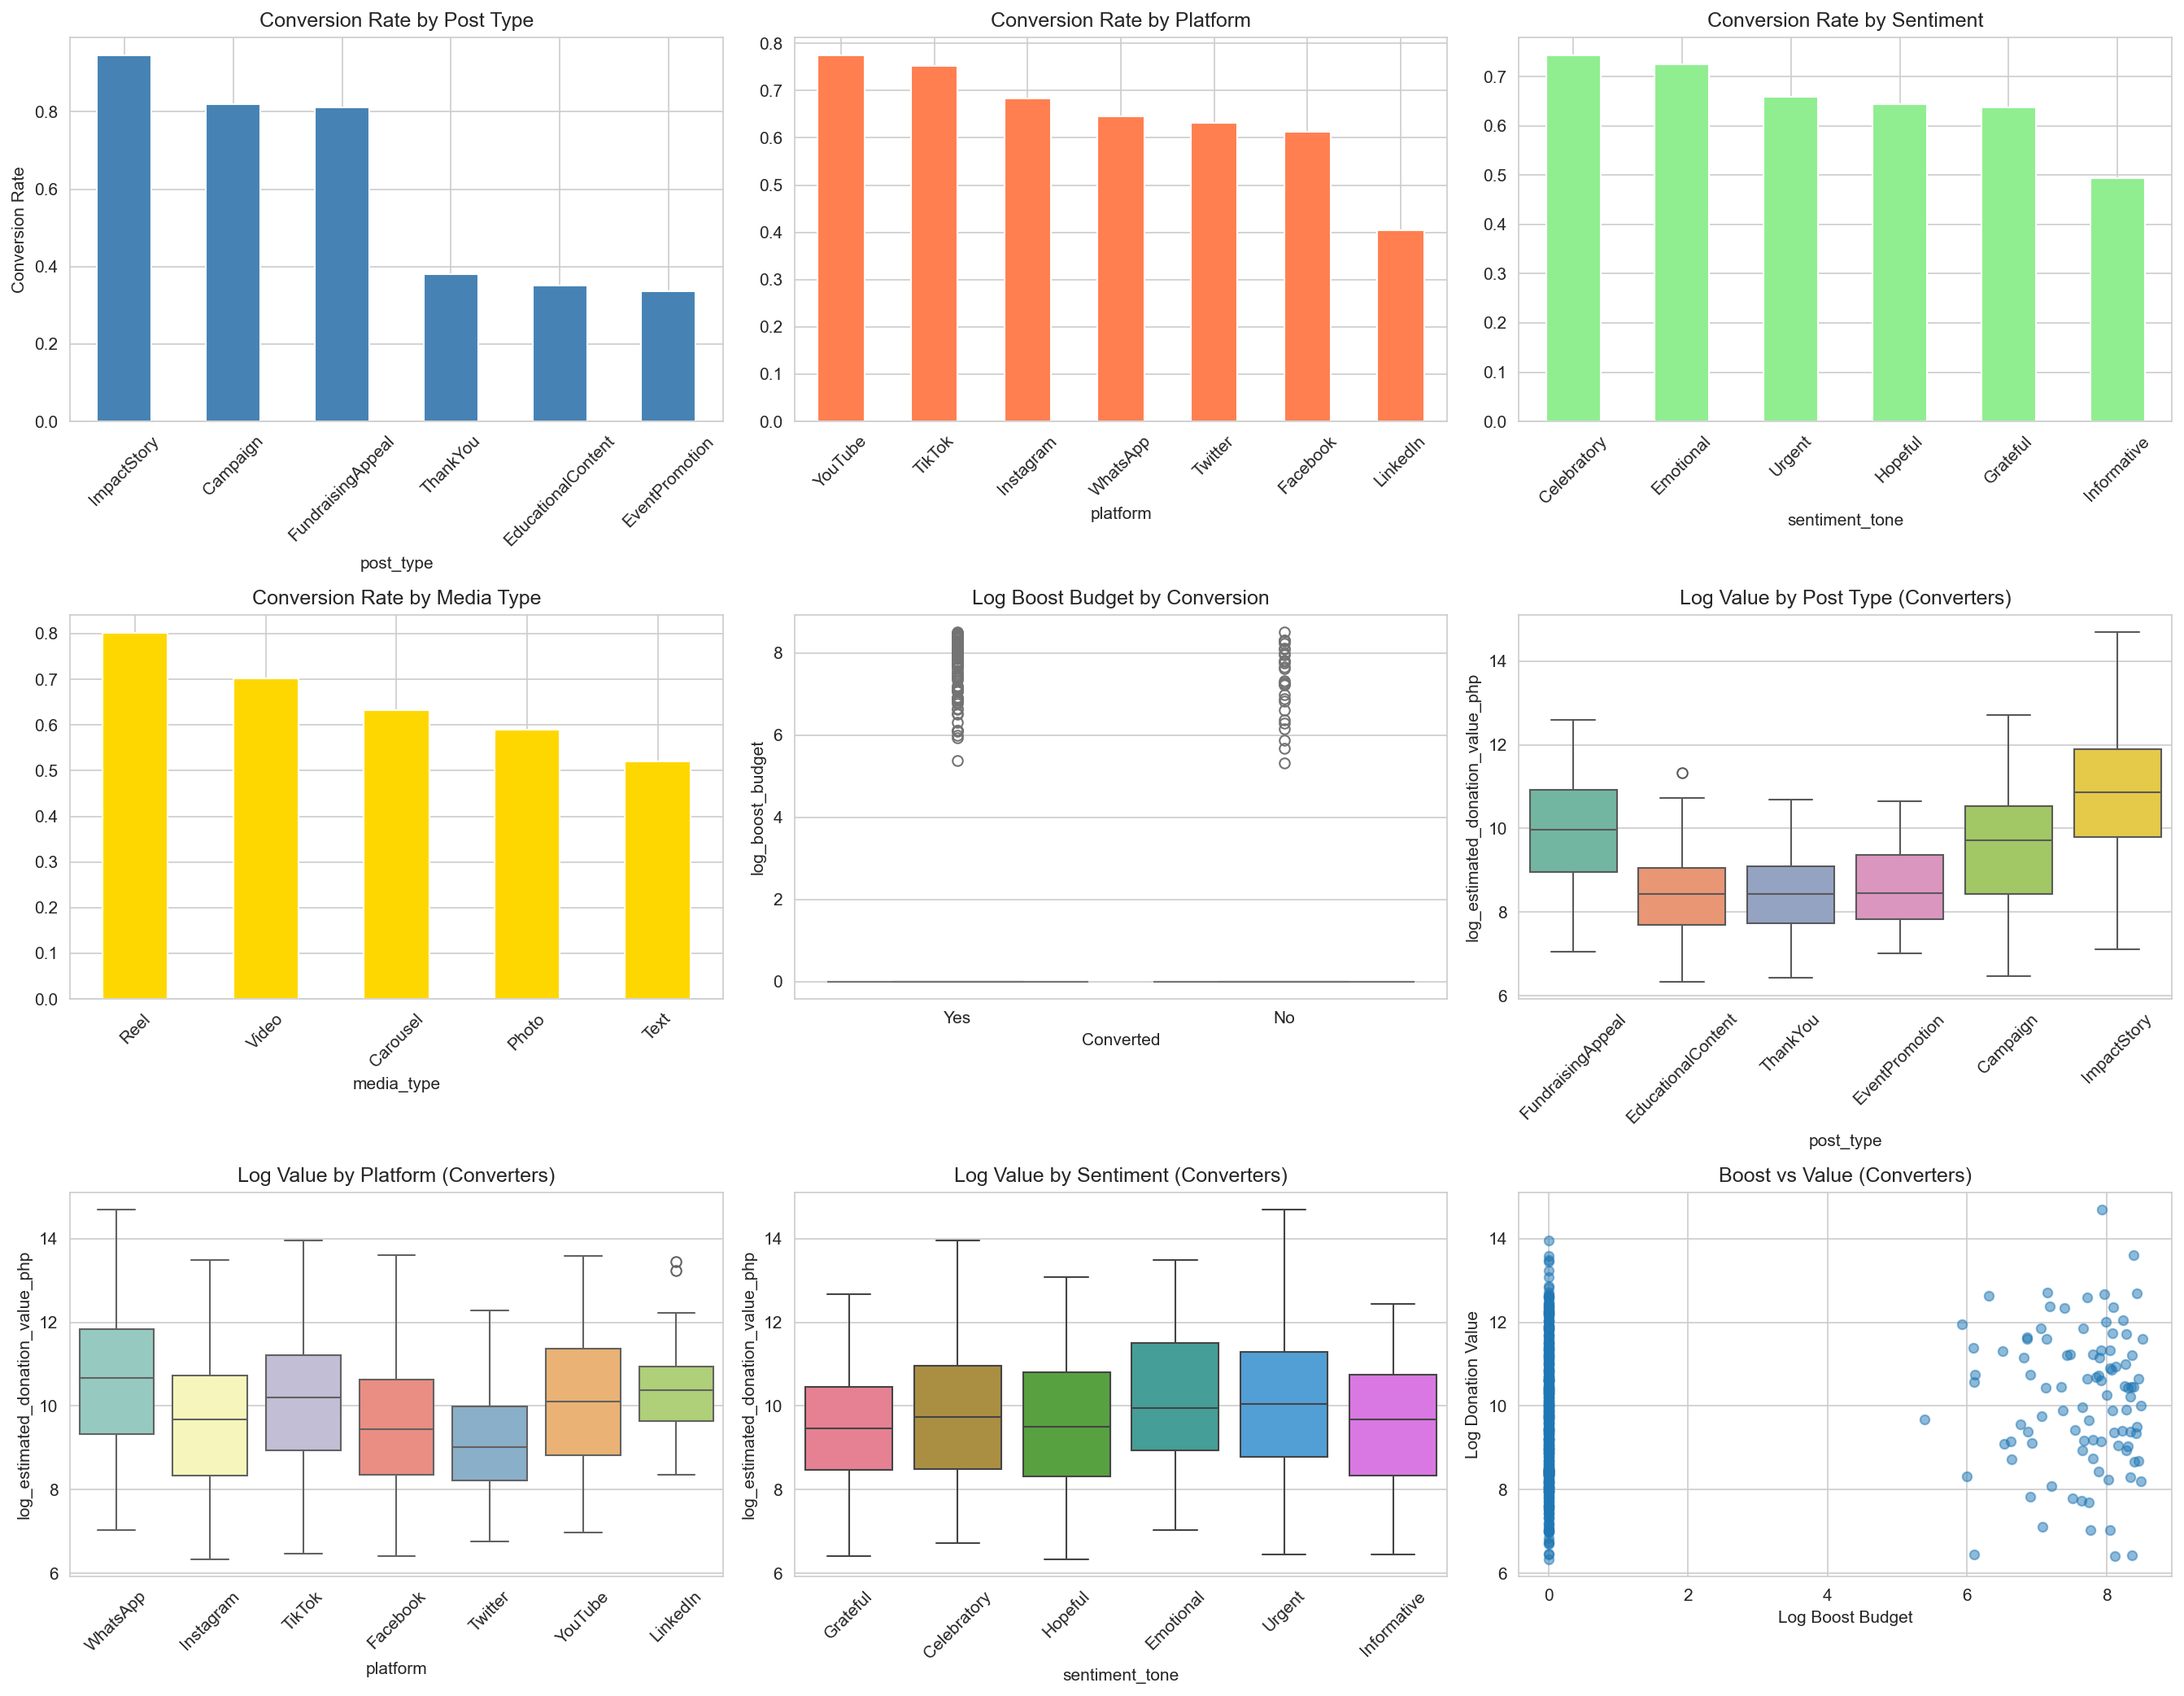

In [17]:
fig = plt.figure(figsize=(18, 14))

# Row 1: Conversion rates by category
ax1 = fig.add_subplot(3, 3, 1)
(df_raw_master.groupby('post_type')['has_any_donations']
 .mean().sort_values(ascending=False)
 .plot(kind='bar', ax=ax1, color='steelblue'))
ax1.set_title('Conversion Rate by Post Type')
ax1.set_ylabel('Conversion Rate')
ax1.tick_params(axis='x', rotation=45)

ax2 = fig.add_subplot(3, 3, 2)
(df_raw_master.groupby('platform')['has_any_donations']
 .mean().sort_values(ascending=False)
 .plot(kind='bar', ax=ax2, color='coral'))
ax2.set_title('Conversion Rate by Platform')
ax2.tick_params(axis='x', rotation=45)

ax3 = fig.add_subplot(3, 3, 3)
(df_raw_master.groupby('sentiment_tone')['has_any_donations']
 .mean().sort_values(ascending=False)
 .plot(kind='bar', ax=ax3, color='lightgreen'))
ax3.set_title('Conversion Rate by Sentiment')
ax3.tick_params(axis='x', rotation=45)

ax4 = fig.add_subplot(3, 3, 4)
(df_raw_master.groupby('media_type')['has_any_donations']
 .mean().sort_values(ascending=False)
 .plot(kind='bar', ax=ax4, color='gold'))
ax4.set_title('Conversion Rate by Media Type')
ax4.tick_params(axis='x', rotation=45)

# Row 2: Boost budget & donation value
ax5 = fig.add_subplot(3, 3, 5)
df_plot = df_raw_master[['has_any_donations', 'log_boost_budget']].copy()
df_plot['Converted'] = df_plot['has_any_donations'].map({0: 'No', 1: 'Yes'})
sns.boxplot(data=df_plot, x='Converted', y='log_boost_budget',
            ax=ax5, palette='pastel')
ax5.set_title('Log Boost Budget by Conversion')

conv = df_raw_master[df_raw_master['has_any_donations'] == 1]

ax6 = fig.add_subplot(3, 3, 6)
sns.boxplot(data=conv, x='post_type',
            y='log_estimated_donation_value_php',
            ax=ax6, palette='Set2')
ax6.set_title('Log Value by Post Type (Converters)')
ax6.tick_params(axis='x', rotation=45)

ax7 = fig.add_subplot(3, 3, 7)
sns.boxplot(data=conv, x='platform',
            y='log_estimated_donation_value_php',
            ax=ax7, palette='Set3')
ax7.set_title('Log Value by Platform (Converters)')
ax7.tick_params(axis='x', rotation=45)

ax8 = fig.add_subplot(3, 3, 8)
sns.boxplot(data=conv, x='sentiment_tone',
            y='log_estimated_donation_value_php',
            ax=ax8, palette='husl')
ax8.set_title('Log Value by Sentiment (Converters)')
ax8.tick_params(axis='x', rotation=45)

ax9 = fig.add_subplot(3, 3, 9)
s = conv[['log_boost_budget', 'log_estimated_donation_value_php']].dropna()
ax9.scatter(s['log_boost_budget'],
            s['log_estimated_donation_value_php'],
            alpha=0.5, s=30)
ax9.set_xlabel('Log Boost Budget')
ax9.set_ylabel('Log Donation Value')
ax9.set_title('Boost vs Value (Converters)')

plt.tight_layout()
plt.savefig(CONFIG['figures_dir'] + 'bivariate_eda.png',
            dpi=CONFIG['dpi'], bbox_inches='tight')
plt.show()

---
## Section 18 — Correlation Heatmap and Multicollinearity Assessment

Identify pairs with |r| > 0.70 that may cause multicollinearity problems
in the regression models.

High correlations (|r| > 0.70):
  month  ↔  quarter:  r = 0.975
  rolling_avg_ref_30d  ↔  rolling_avg_val_30d:  r = 0.935
  log_reach  ↔  log_click_throughs:  r = 0.896
  features_resident_story  ↔  post_type_ImpactStory:  r = 0.875
  is_weekend  ↔  day_of_week_numeric:  r = 0.777


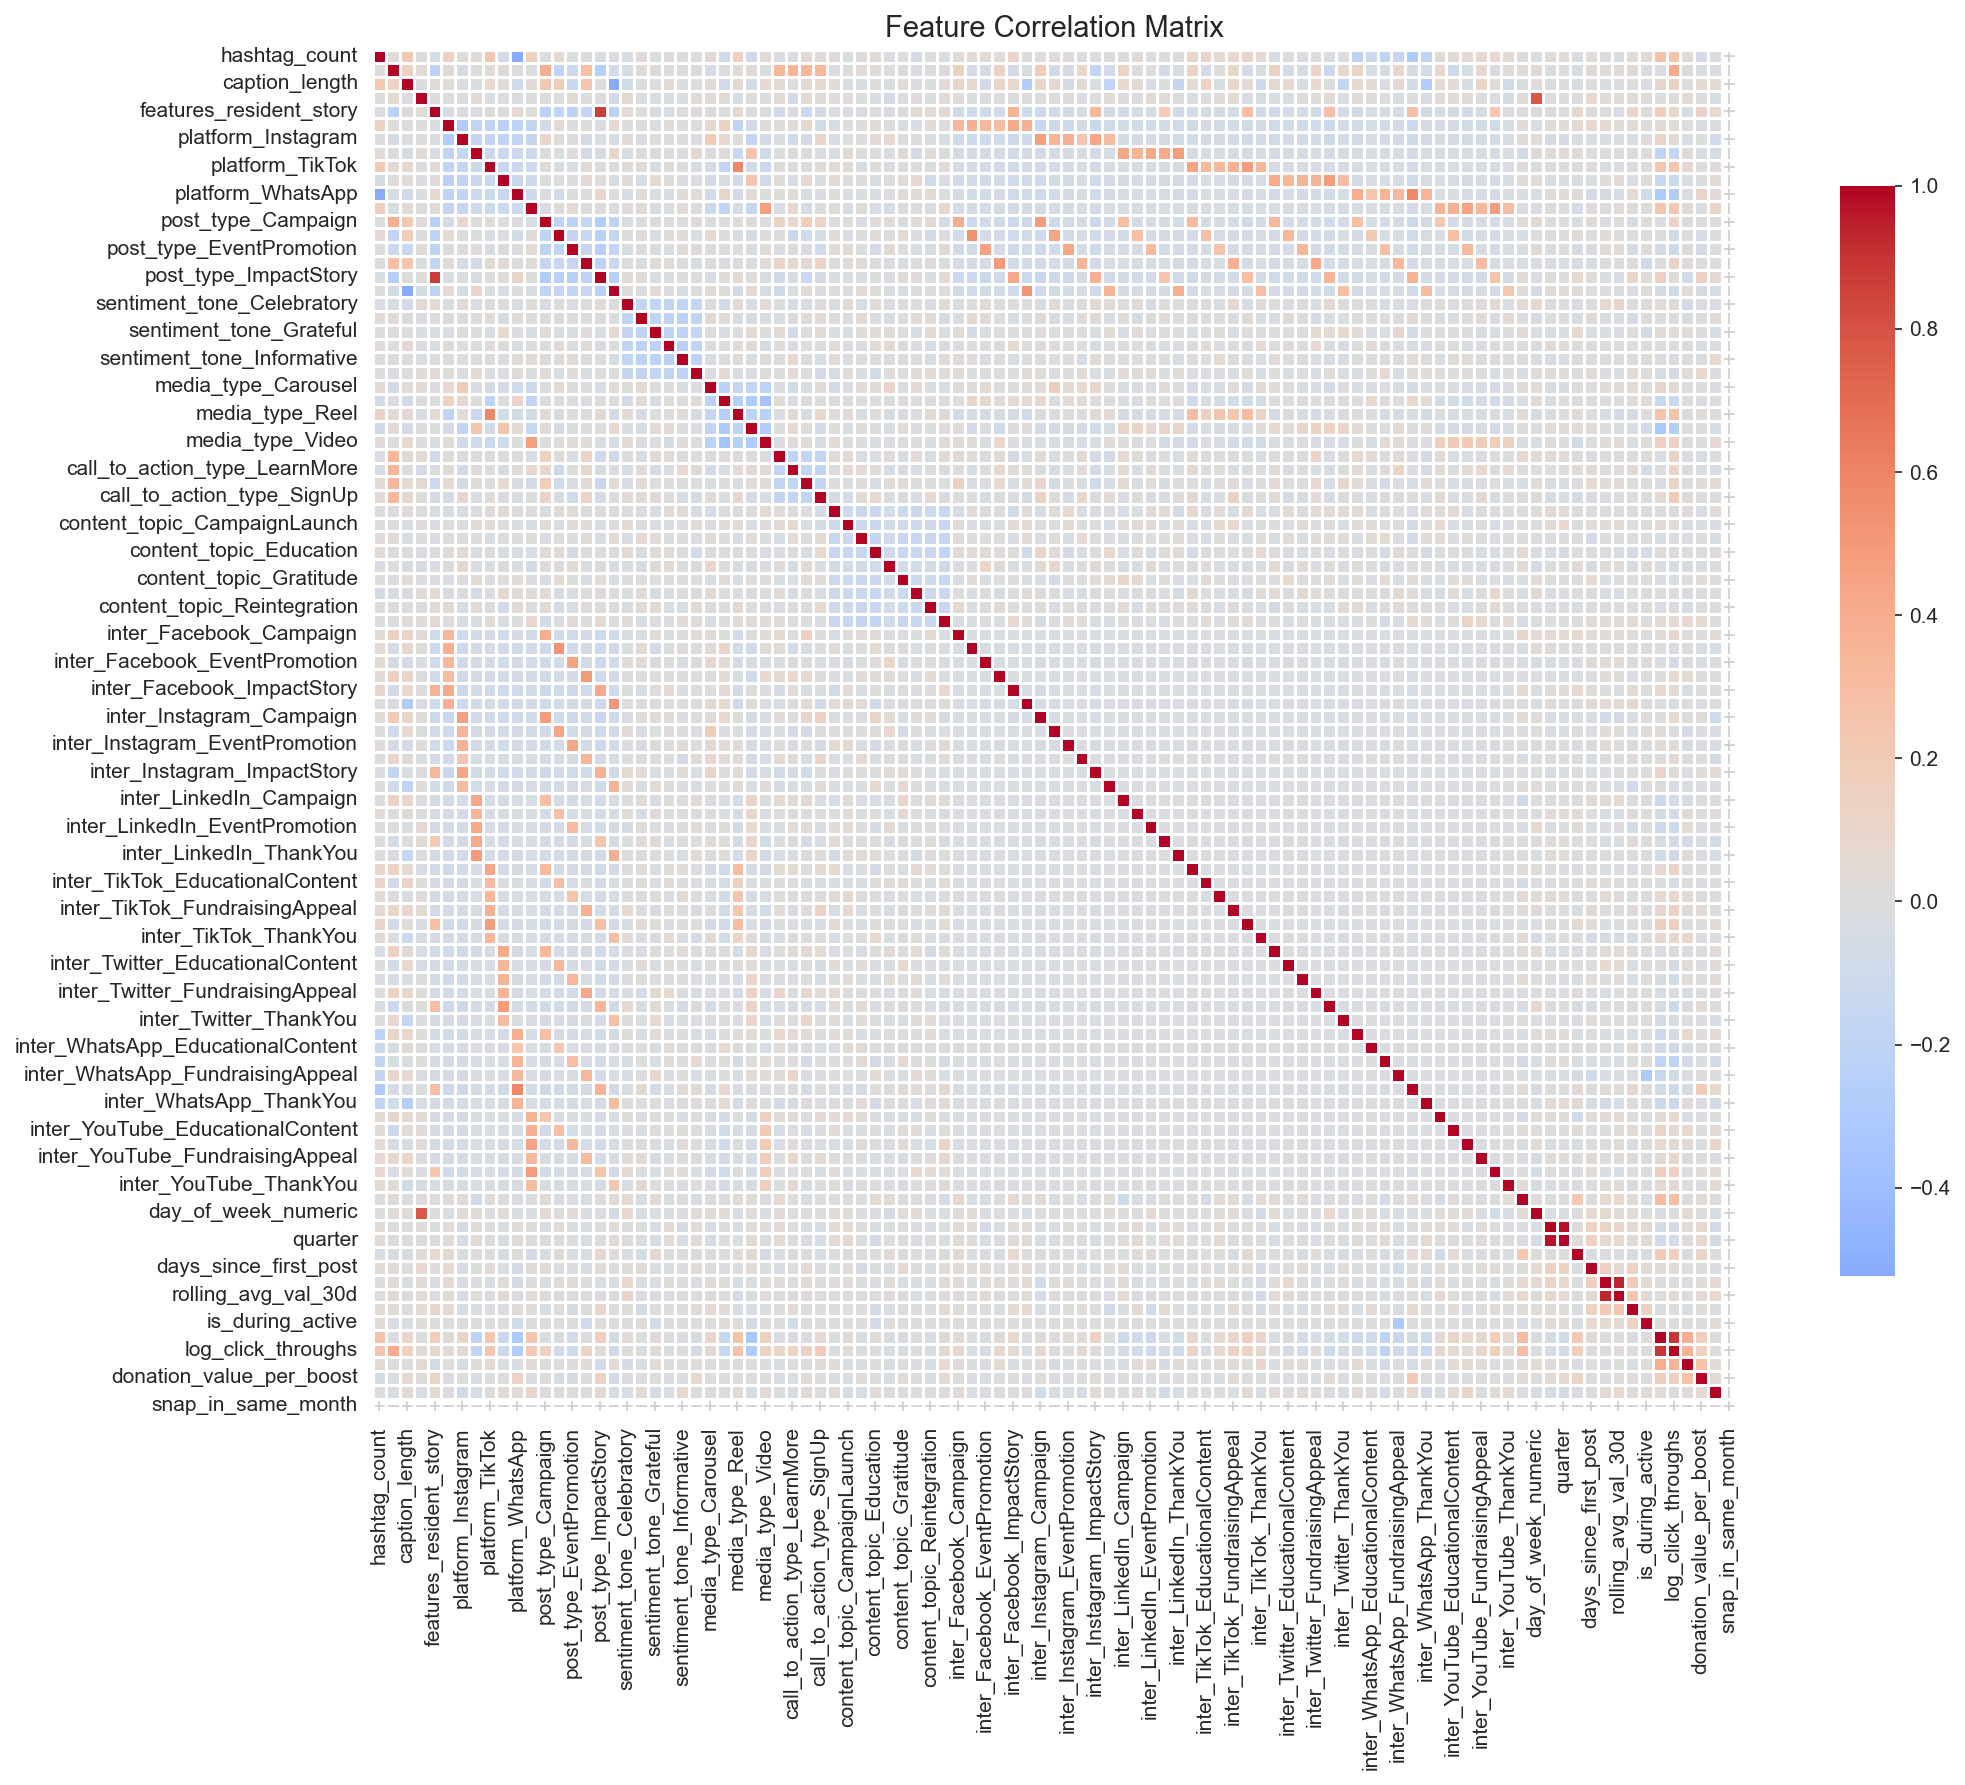

In [18]:
num_features = df_model_features.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_model_features[num_features].corr()

high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.70:
            high_corr.append((corr_matrix.columns[i],
                              corr_matrix.columns[j], round(r, 3)))

print("High correlations (|r| > 0.70):")
if high_corr:
    for f1, f2, r in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f"  {f1}  ↔  {f2}:  r = {r}")
else:
    print("  None found — multicollinearity appears manageable.")

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(CONFIG['figures_dir'] + 'correlation_heatmap.png',
            dpi=CONFIG['dpi'], bbox_inches='tight')
plt.show()

---
## Section 19 — VIF Iterative Reduction

Iteratively drop the feature with the highest VIF until all VIFs fall
below `CONFIG['vif_threshold']` (default 10).  Every drop is logged.

In [19]:
X_vif = df_model_features.select_dtypes(include=[np.number]).copy()
X_vif = X_vif.replace([np.inf, -np.inf], np.nan)
X_vif = X_vif.fillna(X_vif.median())
X_vif = X_vif.loc[:, X_vif.std() > 0]
X_vif = sm.add_constant(X_vif)

print(f"Starting features: {X_vif.shape[1] - 1}")

iteration = 0
while True:
    vif_df = pd.DataFrame({
        'Feature': X_vif.columns,
        'VIF': [variance_inflation_factor(X_vif.values, i)
                for i in range(X_vif.shape[1])]
    })
    max_row = vif_df.loc[vif_df['Feature'] != 'const']
    worst = max_row.loc[max_row['VIF'].idxmax()]

    if worst['VIF'] <= CONFIG['vif_threshold']:
        break

    iteration += 1
    print(f"  Iter {iteration}: drop '{worst['Feature']}'  "
          f"(VIF = {worst['VIF']:.1f})")
    X_vif = X_vif.drop(columns=[worst['Feature']])

vif_reduced_features = [
    c for c in X_vif.columns if c != 'const'
]

final_vif = vif_df[vif_df['Feature'] != 'const']
print(f"\nFinal features: {len(vif_reduced_features)}")
print(f"Max remaining VIF: {final_vif['VIF'].max():.2f}")

Starting features: 98


  Iter 1: drop 'has_cta'  (VIF = inf)


  Iter 2: drop 'platform_Facebook'  (VIF = inf)


  Iter 3: drop 'platform_Instagram'  (VIF = inf)


  Iter 4: drop 'platform_LinkedIn'  (VIF = inf)


...

  Iter 17: drop 'content_topic_AwarenessRaising'  (VIF = inf)


  Iter 18: drop 'log_click_throughs'  (VIF = 55.8)


  Iter 19: drop 'inter_Facebook_ImpactStory'  (VIF = 24.4)


  Iter 20: drop 'quarter'  (VIF = 22.5)



Final features: 78
Max remaining VIF: 9.68


---
## Section 20 — OLS Assumption Testing (Part B: Donation Value)

Test all five OLS assumptions on the converters-only sample:

1. **Linearity** — LOWESS scatter plots
2. **Independence** — Durbin-Watson (autocorrelation risk in time-ordered posts)
3. **Normality of residuals** — Jarque-Bera, Q-Q plot
4. **Homoscedasticity** — Breusch-Pagan test, residuals vs. fitted plot
5. **No perfect multicollinearity** — confirmed via VIF in §19

Converters sample: n = 522


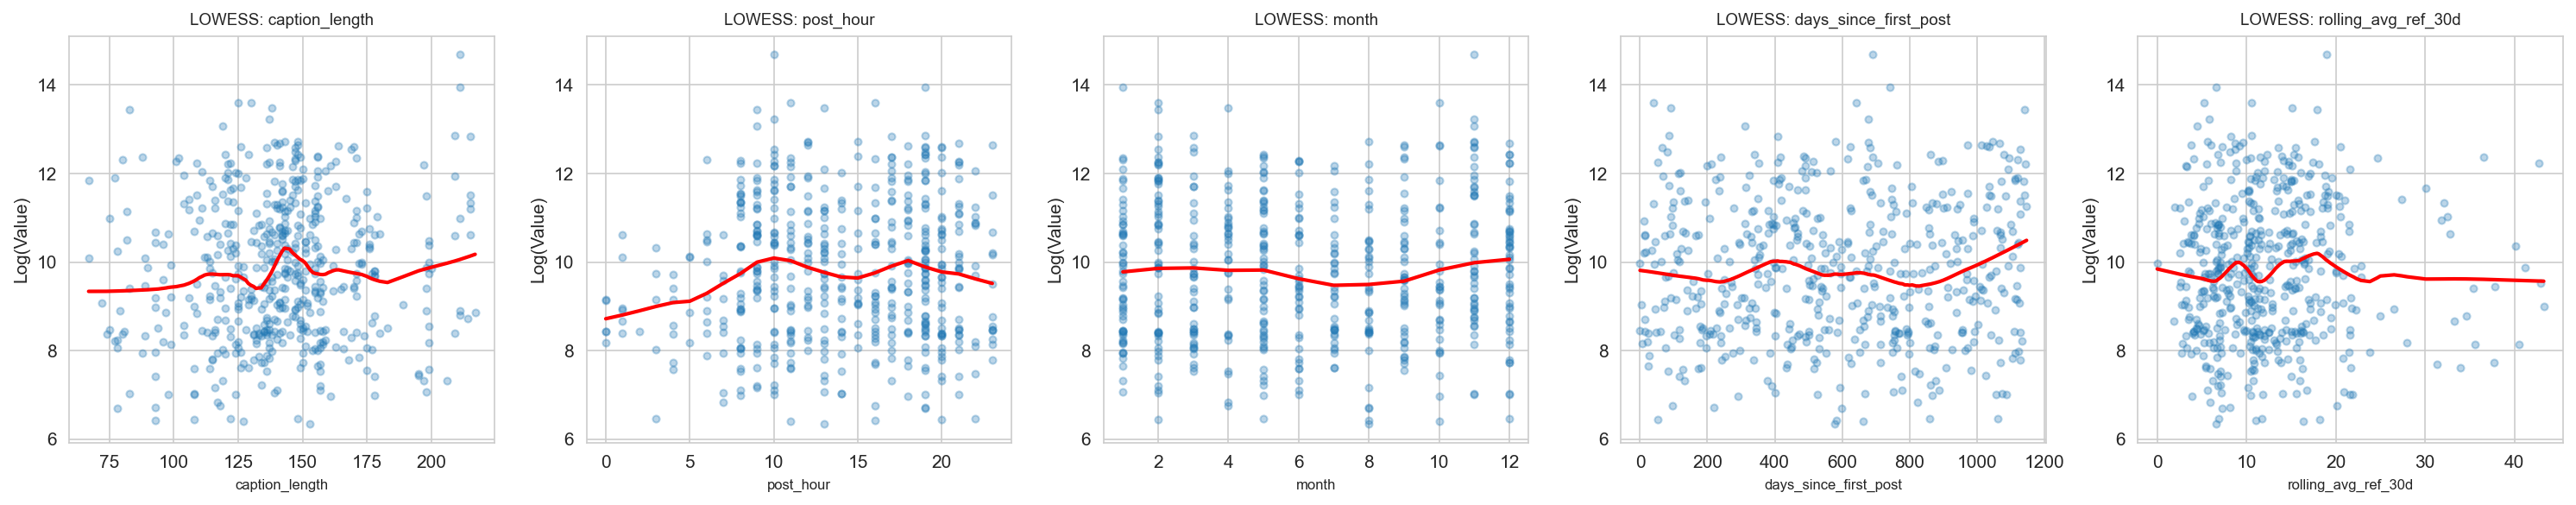


Durbin-Watson: 2.054  (≈2 is ideal)
Jarque-Bera: stat = 9.96, p = 0.0069


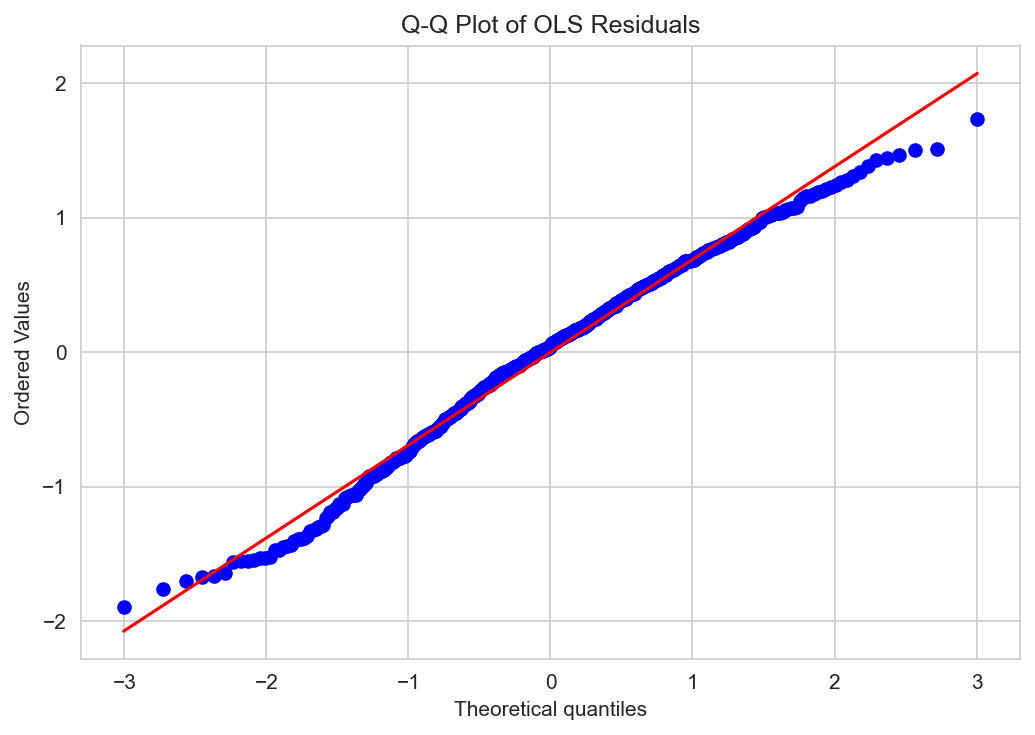

Breusch-Pagan: stat = 85.27, p = 0.2683


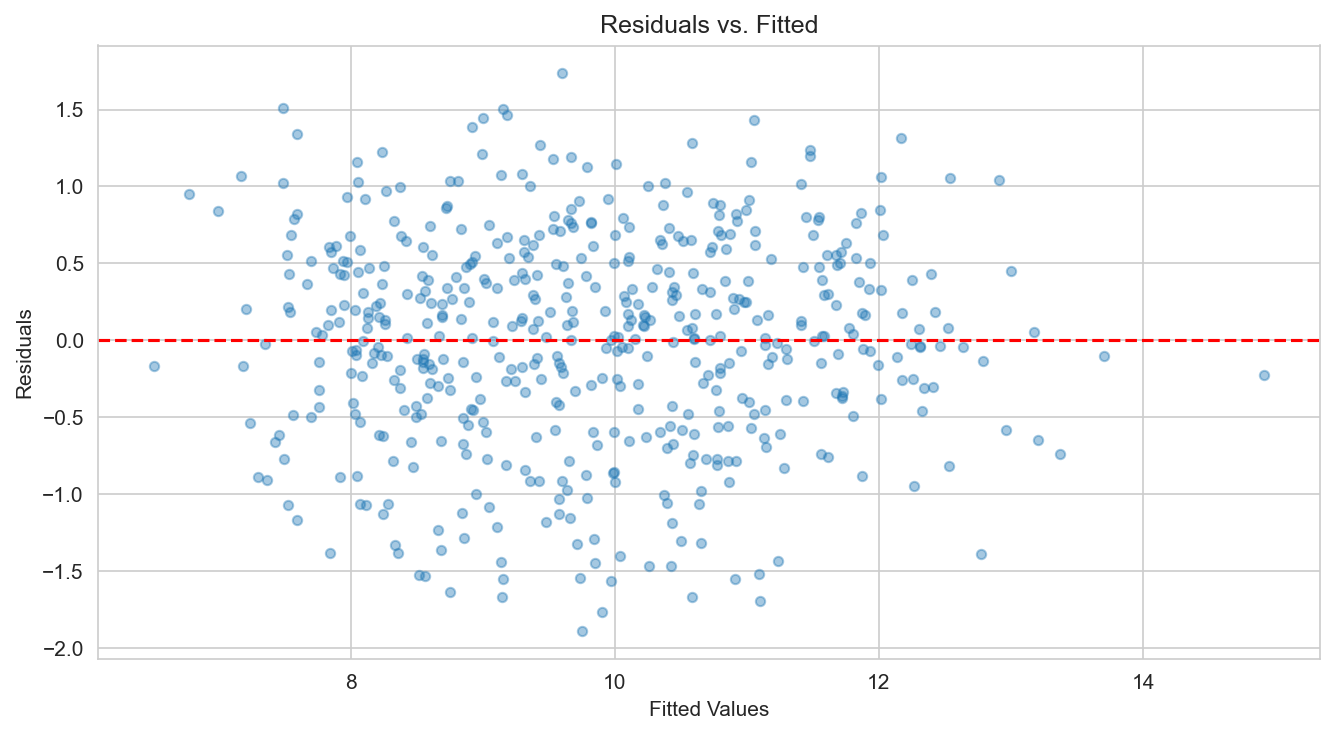


OLS Assumption Summary
  Durbin-Watson:  2.054
  Jarque-Bera p:  0.0069  ⚠
  Breusch-Pagan p: 0.2683  ✓


In [20]:
converters_idx = df_raw_master[df_raw_master['has_any_donations'] == 1].index
X_conv = df_model_features.loc[converters_idx, vif_reduced_features].copy()
y_conv = df_raw_master.loc[converters_idx,
                           'log_estimated_donation_value_php'].copy()
X_conv_c = sm.add_constant(X_conv)

print(f"Converters sample: n = {len(X_conv)}")

# ── 1. Linearity (LOWESS on first 5 continuous features) ──
cont_feats = [c for c in X_conv.columns
              if X_conv[c].nunique() > 10][:5]

if cont_feats:
    fig, axes = plt.subplots(1, len(cont_feats),
                             figsize=(4 * len(cont_feats), 4))
    if len(cont_feats) == 1:
        axes = [axes]
    for ax, feat in zip(axes, cont_feats):
        ax.scatter(X_conv[feat], y_conv, alpha=0.3, s=15)
        lo = lowess(y_conv.values, X_conv[feat].values, frac=0.3)
        ax.plot(lo[:, 0], lo[:, 1], 'r-', linewidth=2)
        ax.set_xlabel(feat, fontsize=8)
        ax.set_ylabel('Log(Value)')
        ax.set_title(f'LOWESS: {feat}', fontsize=9)
    plt.tight_layout()
    plt.savefig(CONFIG['figures_dir'] + 'ols_linearity_lowess.png',
                dpi=CONFIG['dpi'], bbox_inches='tight')
    plt.show()

# ── 2. Independence (Durbin-Watson) ──
temp_model = sm.OLS(y_conv, X_conv_c).fit()
dw = durbin_watson(temp_model.resid)
print(f"\nDurbin-Watson: {dw:.3f}  (≈2 is ideal)")

# ── 3. Normality ──
jb_stat, jb_p = jarque_bera(temp_model.resid)
print(f"Jarque-Bera: stat = {jb_stat:.2f}, p = {jb_p:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
probplot(temp_model.resid, dist='norm', plot=ax)
ax.set_title('Q-Q Plot of OLS Residuals')
plt.tight_layout()
plt.savefig(CONFIG['figures_dir'] + 'ols_qq_plot.png',
            dpi=CONFIG['dpi'], bbox_inches='tight')
plt.show()

# ── 4. Homoscedasticity ──
bp_stat, bp_p, _, _ = het_breuschpagan(temp_model.resid, X_conv_c)
print(f"Breusch-Pagan: stat = {bp_stat:.2f}, p = {bp_p:.4f}")
use_robust_se = bp_p < CONFIG['significance_level']
if use_robust_se:
    print("→ Heteroscedasticity detected — will use HC3 robust SEs.")

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(temp_model.fittedvalues, temp_model.resid, alpha=0.4, s=20)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs. Fitted')
plt.tight_layout()
plt.savefig(CONFIG['figures_dir'] + 'ols_residuals_fitted.png',
            dpi=CONFIG['dpi'], bbox_inches='tight')
plt.show()

print("\n" + "=" * 50)
print("OLS Assumption Summary")
print("=" * 50)
print(f"  Durbin-Watson:  {dw:.3f}")
print(f"  Jarque-Bera p:  {jb_p:.4f}  {'✓' if jb_p > 0.05 else '⚠'}")
print(f"  Breusch-Pagan p: {bp_p:.4f}  {'✓' if bp_p > 0.05 else '⚠ → HC3'}")

---
## Section 21 — Logistic Regression Assumption Testing (Part A: Conversion)

Check key assumptions before fitting the logistic model:

- **Sample size:** At least 10 events per predictor
- **Multicollinearity:** VIFs already reduced in §19
- **Quasi/perfect separation:** Zero-variance dummies removed

In [21]:
X_logit_check = df_model_features[vif_reduced_features].copy()
y_logit_check = df_raw_master['has_any_donations'].copy()

n_events = (y_logit_check == 1).sum()
n_pred = len(vif_reduced_features)
epp = n_events / n_pred

print("Logistic Regression Assumption Check")
print("=" * 50)
print(f"  Total sample:         {len(X_logit_check):,}")
print(f"  Class 0 (no convert): {(y_logit_check == 0).sum():,}")
print(f"  Class 1 (convert):    {n_events:,}")
print(f"  Predictors:           {n_pred}")
print(f"  Events per predictor: {epp:.1f}  "
      f"{'✓ adequate' if epp >= 10 else '⚠ low'}")

Logistic Regression Assumption Check
  Total sample:         812
  Class 0 (no convert): 290
  Class 1 (convert):    522
  Predictors:           78
  Events per predictor: 6.7  ⚠ low




---

## Part 3 — Modeling & Feature Selection

# Section 3 — Modeling & Feature Selection

Two models are fit: (A) logistic regression on `has_any_donations` (conversion); (B) OLS on `log_donation_value` (value, conditional on conversion). OLS assumptions are verified. VIF reduction is applied. Purposeful variable selection removes theoretically weak features. Odds ratios and coefficient plots are produced for both models.

---
## Section 22 — Part A: Logistic Regression — What Makes a Post Convert?

Fit `statsmodels.Logit` on **all posts** with the binary target
`has_any_donations`.  This is the first stage of the hurdle model.

> **Question answered:** What post characteristics are associated with
> generating *any* donations at all?

In [22]:
X_logit = df_model_features[vif_reduced_features].copy()
X_logit = X_logit.loc[:, X_logit.std() > 0]
y_logit = df_raw_master['has_any_donations'].copy()

X_logit_c = sm.add_constant(X_logit)
print(f"Fitting Logistic Regression  (n = {len(X_logit_c):,}, "
      f"p = {X_logit_c.shape[1] - 1})")

logit_result = sm.Logit(y_logit, X_logit_c).fit(
    method='bfgs', maxiter=1000, disp=False
)

print(logit_result.summary())
print(f"\nPseudo R²: {logit_result.prsquared:.4f}")
sig_logit = (logit_result.pvalues[1:] < CONFIG['significance_level']).sum()
print(f"Significant features (p < {CONFIG['significance_level']}): {sig_logit}")

Fitting Logistic Regression  (n = 812, p = 78)


                           Logit Regression Results                           
Dep. Variable:      has_any_donations   No. Observations:                  812
Model:                          Logit   Df Residuals:                      733
Method:                           MLE   Df Model:                           78
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.9211
Time:                        16:29:44   Log-Likelihood:                -41.763
converged:                       True   LL-Null:                       -529.23
Covariance Type:            nonrobust   LLR p-value:                5.699e-155
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                               -196.5194        nan        nan        nan         nan         nan
hashtag_count                         -1.1504        nan   

---
## Section 23 — Part A: Odds Ratios, Confidence Intervals & Forest Plot

Odds ratios (OR) translate logistic coefficients into interpretable
multipliers:

> *"Posts with \[feature\] are OR times more likely to generate any
> donation referrals compared to the baseline, holding other factors constant."*

In [23]:
or_df = pd.DataFrame({
    'Feature': logit_result.params.index[1:],
    'Coef': logit_result.params.values[1:],
    'SE': logit_result.bse.values[1:],
    'p': logit_result.pvalues.values[1:]
})
or_df['OR'] = np.exp(or_df['Coef'])
or_df['CI_lo'] = np.exp(or_df['Coef'] - 1.96 * or_df['SE'])
or_df['CI_hi'] = np.exp(or_df['Coef'] + 1.96 * or_df['SE'])

sig = or_df[or_df['p'] < CONFIG['significance_level']].sort_values('OR')
print(f"Significant odds ratios: {len(sig)}")
print(sig[['Feature', 'OR', 'CI_lo', 'CI_hi', 'p']].to_string(index=False))

if len(sig):
    fig, ax = plt.subplots(figsize=(10, max(4, len(sig) * 0.45)))
    y_pos = np.arange(len(sig))
    ax.scatter(sig['OR'], y_pos, s=80, color='steelblue', zorder=3)
    ax.hlines(y_pos, sig['CI_lo'], sig['CI_hi'],
              colors='steelblue', linewidth=2)
    ax.axvline(1, color='red', linestyle='--', linewidth=1.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sig['Feature'], fontsize=8)
    ax.set_xlabel('Odds Ratio (95% CI)')
    ax.set_title('Part A — Logistic Regression: Significant Odds Ratios')
    plt.tight_layout()
    plt.savefig(CONFIG['figures_dir'] + 'logistic_odds_ratios.png',
                dpi=CONFIG['dpi'], bbox_inches='tight')
    plt.show()

    print("\n" + "=" * 60)
    print("PLAIN-ENGLISH INTERPRETATIONS (Logistic)")
    print("=" * 60)
    for _, row in sig.sort_values('OR', ascending=False).iterrows():
        direction = "more" if row['OR'] > 1 else "less"
        print(f"\n  {row['Feature']}  (OR = {row['OR']:.2f}, "
              f"p = {row['p']:.4f}):")
        print(f"    Posts with {row['Feature']} are {row['OR']:.2f} times "
              f"{direction} likely to generate any donation referrals "
              f"compared to the baseline, holding other factors constant.")

Significant odds ratios: 0
Empty DataFrame
Columns: [Feature, OR, CI_lo, CI_hi, p]
Index: []


---
## Section 24 — Part B: OLS Regression — What Drives Donation Value?

Fit `statsmodels.OLS` on **converters only** with the log-transformed
continuous target.  Use HC3 robust standard errors if heteroscedasticity
was detected.

> **Interpretation:** A coefficient of β means a one-unit increase in the
> feature is associated with approximately `(exp(β) − 1) × 100%` change
> in estimated donation value.

In [24]:
converters_idx = df_raw_master[df_raw_master['has_any_donations'] == 1].index
X_ols = df_model_features.loc[converters_idx, vif_reduced_features].copy()
y_ols = df_raw_master.loc[converters_idx,
                          'log_estimated_donation_value_php'].copy()
X_ols_c = sm.add_constant(X_ols)

print(f"Fitting OLS Regression  (n = {len(X_ols_c):,}, converters only)")

if use_robust_se:
    ols_result = sm.OLS(y_ols, X_ols_c).fit(cov_type='HC3')
    print("Using HC3 robust standard errors.")
else:
    ols_result = sm.OLS(y_ols, X_ols_c).fit()

print(ols_result.summary())
print(f"\nAdjusted R²: {ols_result.rsquared_adj:.4f}")
print(f"F-statistic: {ols_result.fvalue:.2f}  (p = {ols_result.f_pvalue:.4f})")
sig_ols = (ols_result.pvalues[1:] < CONFIG['significance_level']).sum()
print(f"Significant features (p < {CONFIG['significance_level']}): {sig_ols}")

Fitting OLS Regression  (n = 522, converters only)
                                   OLS Regression Results                                   
Dep. Variable:     log_estimated_donation_value_php   R-squared:                       0.810
Model:                                          OLS   Adj. R-squared:                  0.777
Method:                               Least Squares   F-statistic:                     24.27
Date:                              Wed, 08 Apr 2026   Prob (F-statistic):          2.44e-118
Time:                                      16:29:44   Log-Likelihood:                -546.67
No. Observations:                               522   AIC:                             1251.
Df Residuals:                                   443   BIC:                             1588.
Df Model:                                        78                                         
Covariance Type:                          nonrobust                                         
                   

---
## Section 25 — Part B: OLS Coefficient Plot and Interpretation

Each significant coefficient translates to a percentage change in
donation value (since the target is log-transformed).

Significant OLS coefficients: 37


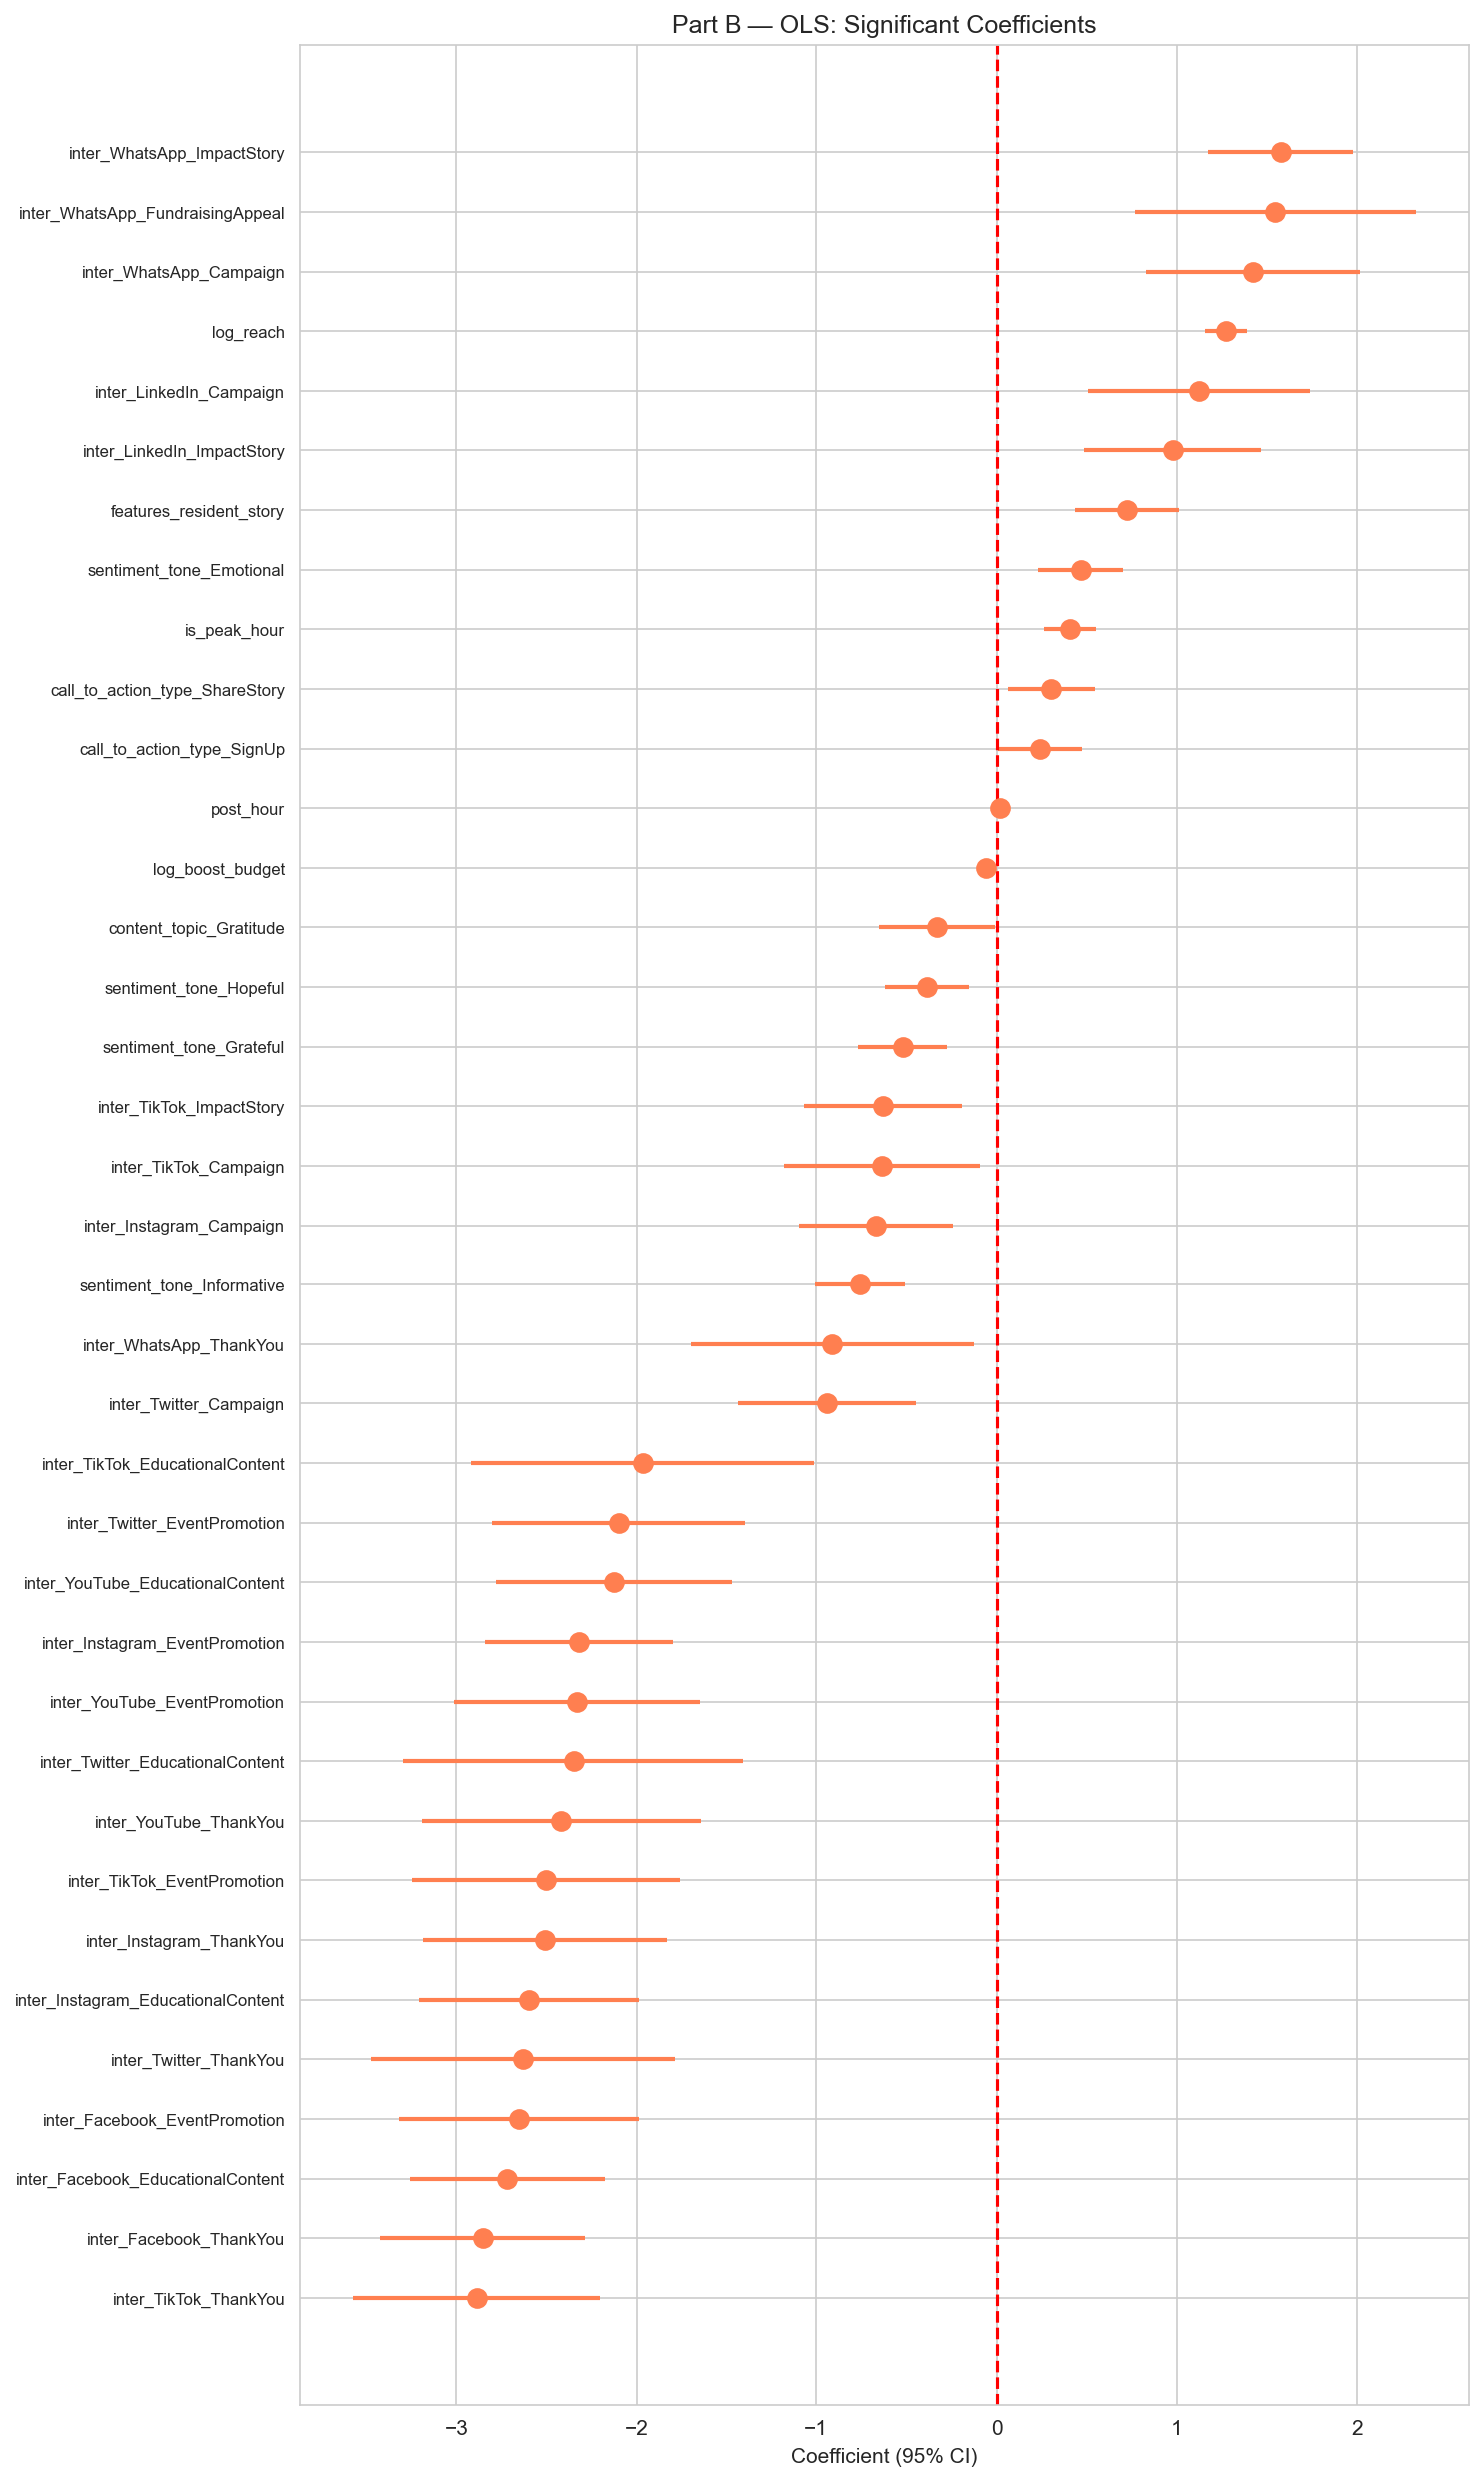


Top 5 value-driving features:
  1. inter_WhatsApp_ImpactStory: +382.9%
  2. inter_WhatsApp_FundraisingAppeal: +368.8%
  3. inter_WhatsApp_Campaign: +314.3%
  4. log_reach: +257.5%
  5. inter_LinkedIn_Campaign: +207.8%

Bottom 5 value-decreasing features:
  1. inter_TikTok_ThankYou: -94.4%
  2. inter_Facebook_ThankYou: -94.2%
  3. inter_Facebook_EducationalContent: -93.4%
  4. inter_Facebook_EventPromotion: -93.0%
  5. inter_Twitter_ThankYou: -92.8%

PLAIN-ENGLISH INTERPRETATIONS (OLS)

  inter_WhatsApp_ImpactStory  (coef = 1.575, p = 0.0000):
    Posts with inter_WhatsApp_ImpactStory are associated with approximately 382.9% higher estimated donation value compared to the baseline, holding all other characteristics constant. This suggests the team should prioritize inter_WhatsApp_ImpactStory for donation-focused content.

  inter_WhatsApp_FundraisingAppeal  (coef = 1.545, p = 0.0001):
    Posts with inter_WhatsApp_FundraisingAppeal are associated with approximately 368.8% higher estima

In [25]:
coef_df = pd.DataFrame({
    'Feature': ols_result.params.index[1:],
    'Coef': ols_result.params.values[1:],
    'SE': ols_result.bse.values[1:],
    'p': ols_result.pvalues.values[1:]
})
coef_df['CI_lo'] = coef_df['Coef'] - 1.96 * coef_df['SE']
coef_df['CI_hi'] = coef_df['Coef'] + 1.96 * coef_df['SE']
coef_df['pct_change'] = (np.exp(coef_df['Coef']) - 1) * 100

sig_coef = coef_df[coef_df['p'] < CONFIG['significance_level']].sort_values('Coef')
print(f"Significant OLS coefficients: {len(sig_coef)}")

if len(sig_coef):
    fig, ax = plt.subplots(figsize=(10, max(4, len(sig_coef) * 0.45)))
    y_pos = np.arange(len(sig_coef))
    ax.scatter(sig_coef['Coef'], y_pos, s=80, color='coral', zorder=3)
    ax.hlines(y_pos, sig_coef['CI_lo'], sig_coef['CI_hi'],
              colors='coral', linewidth=2)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sig_coef['Feature'], fontsize=8)
    ax.set_xlabel('Coefficient (95% CI)')
    ax.set_title('Part B — OLS: Significant Coefficients')
    plt.tight_layout()
    plt.savefig(CONFIG['figures_dir'] + 'ols_coefficients.png',
                dpi=CONFIG['dpi'], bbox_inches='tight')
    plt.show()

    print("\nTop 5 value-driving features:")
    for i, (_, row) in enumerate(
            sig_coef.sort_values('Coef', ascending=False).head(5).iterrows(), 1):
        print(f"  {i}. {row['Feature']}: +{row['pct_change']:.1f}%")

    print("\nBottom 5 value-decreasing features:")
    for i, (_, row) in enumerate(
            sig_coef.sort_values('Coef').head(5).iterrows(), 1):
        print(f"  {i}. {row['Feature']}: {row['pct_change']:.1f}%")

    print("\n" + "=" * 60)
    print("PLAIN-ENGLISH INTERPRETATIONS (OLS)")
    print("=" * 60)
    for _, row in sig_coef.sort_values('Coef', ascending=False).iterrows():
        direction = "higher" if row['pct_change'] > 0 else "lower"
        action = "prioritize" if row['pct_change'] > 0 else "de-prioritize"
        print(f"\n  {row['Feature']}  (coef = {row['Coef']:.3f}, "
              f"p = {row['p']:.4f}):")
        print(f"    Posts with {row['Feature']} are associated with "
              f"approximately {abs(row['pct_change']):.1f}% {direction} "
              f"estimated donation value compared to the baseline, "
              f"holding all other characteristics constant. "
              f"This suggests the team should {action} "
              f"{row['Feature']} for donation-focused content.")

---
## Section 26 — Engagement vs. Donation Gap Analysis

> **The most strategically valuable finding:** Is the "best" content for
> engagement the same as the "best" for donations?
>
> If not, the organization may be over-investing in attention-optimized
> content at the expense of donation-optimized content.

By Post Type:
                    avg_engagement  avg_referrals  conv_rate  eng_rank  \
post_type                                                                
Campaign                     0.109          8.994      0.821         1   
FundraisingAppeal            0.108         14.078      0.811         2   
ThankYou                     0.098          0.839      0.381         3   
ImpactStory                  0.097         36.394      0.946         4   
EventPromotion               0.094          1.046      0.336         5   
EducationalContent           0.088          0.842      0.351         6   

                    don_rank  
post_type                     
Campaign                   3  
FundraisingAppeal          2  
ThankYou                   6  
ImpactStory                1  
EventPromotion             4  
EducationalContent         5  

By Platform:
           avg_engagement  avg_value  eng_rank  val_rank
platform                                                
Instagram        

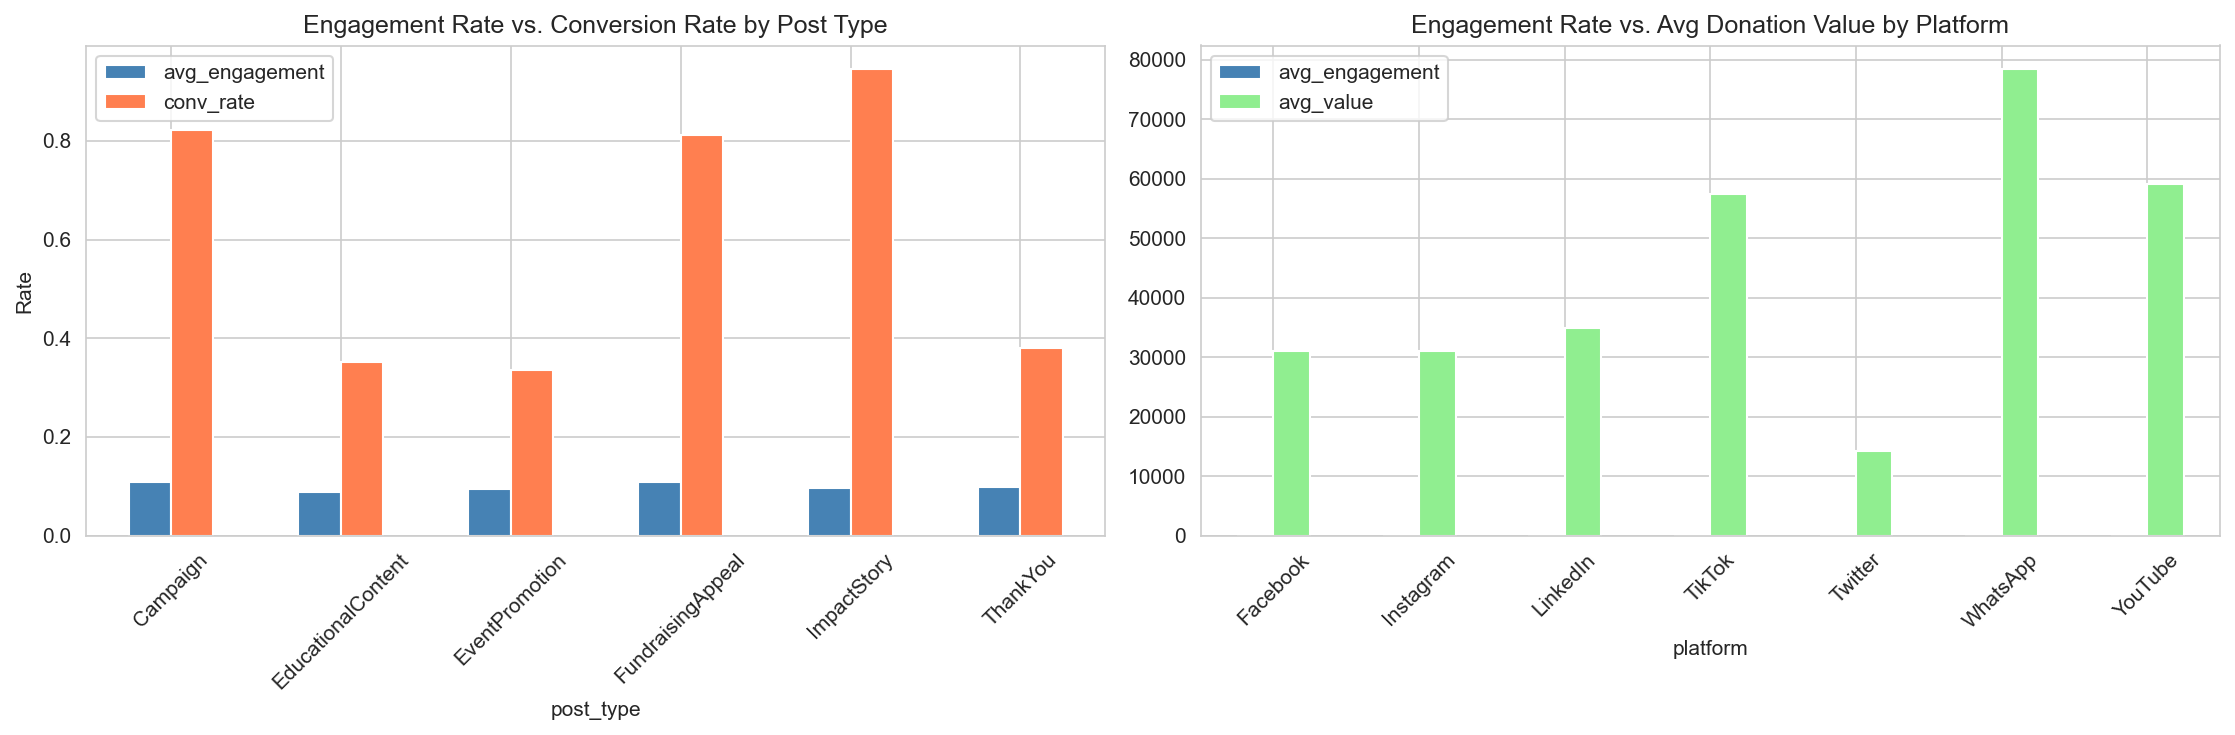

In [26]:
gap_type = df_raw_master.groupby('post_type').agg(
    avg_engagement=('engagement_rate', 'mean'),
    avg_referrals=('donation_referrals', 'mean'),
    conv_rate=('has_any_donations', 'mean')
).round(3)
gap_type['eng_rank'] = gap_type['avg_engagement'].rank(ascending=False).astype(int)
gap_type['don_rank'] = gap_type['avg_referrals'].rank(ascending=False).astype(int)

print("By Post Type:")
print(gap_type.sort_values('avg_engagement', ascending=False))

gap_plat = df_raw_master.groupby('platform').agg(
    avg_engagement=('engagement_rate', 'mean'),
    avg_value=('estimated_donation_value_php', 'mean')
).round(2)
gap_plat['eng_rank'] = gap_plat['avg_engagement'].rank(ascending=False).astype(int)
gap_plat['val_rank'] = gap_plat['avg_value'].rank(ascending=False).astype(int)

print("\nBy Platform:")
print(gap_plat.sort_values('avg_engagement', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

gap_type[['avg_engagement', 'conv_rate']].plot(
    kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Engagement Rate vs. Conversion Rate by Post Type')
axes[0].set_ylabel('Rate')
axes[0].tick_params(axis='x', rotation=45)

gap_plat[['avg_engagement', 'avg_value']].plot(
    kind='bar', ax=axes[1], color=['steelblue', 'lightgreen'])
axes[1].set_title('Engagement Rate vs. Avg Donation Value by Platform')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(CONFIG['figures_dir'] + 'engagement_donation_gap.png',
            dpi=CONFIG['dpi'], bbox_inches='tight')
plt.show()

---
## Section 27 — Platform Efficiency Analysis

The **platform efficiency table** answers the question every fundraising
director asks: *"Where should I spend my social media budget?"*

| Metric | Meaning |
|---|---|
| Avg Value / Post | Average donation value generated per post |
| Avg Budget / Post | Average boost spend per post |
| ROAS | Return on Ad Spend (Value ÷ Budget) |
| Conv Rate | Fraction of posts generating any donations |

In [27]:
eff = df_raw_master.groupby('platform').agg(
    n_posts=('post_id', 'count'),
    avg_value=('estimated_donation_value_php', 'mean'),
    avg_budget=('boost_budget_php', 'mean'),
    conv_rate=('has_any_donations', 'mean')
).round(2)
eff['ROAS'] = (eff['avg_value'] / eff['avg_budget']).replace(
    [np.inf, -np.inf], 0
).round(2)

print("Platform Efficiency:")
print(eff.sort_values('avg_value', ascending=False).to_string())

print("\n--- By Post Type ---")
eff_type = df_raw_master.groupby('post_type').agg(
    n_posts=('post_id', 'count'),
    avg_value=('estimated_donation_value_php', 'mean'),
    conv_rate=('has_any_donations', 'mean')
).round(2)
print(eff_type.sort_values('avg_value', ascending=False).to_string())

platform_efficiency_dict = eff.to_dict()

Platform Efficiency:
           n_posts  avg_value  avg_budget  conv_rate   ROAS
platform                                                   
WhatsApp        93   78438.10     2477.83       0.65  31.66
YouTube         71   59060.76     2591.47       0.77  22.79
TikTok          89   57424.57     2515.91       0.75  22.82
LinkedIn        79   34921.29     2998.36       0.41  11.65
Facebook       199   31086.19     2233.89       0.61  13.92
Instagram      164   30989.33     2409.88       0.68  12.86
Twitter        117   14264.21     2054.39       0.63   6.94

--- By Post Type ---
                    n_posts  avg_value  conv_rate
post_type                                        
ImpactStory             203  116160.67       0.95
FundraisingAppeal        90   36155.81       0.81
Campaign                156   28141.30       0.82
EducationalContent      114    3183.23       0.35
ThankYou                118    2927.61       0.38
EventPromotion          131    2762.69       0.34


---
## Section 28 — Feature Selection and Purposeful Reduction

Identify features that are both **statistically insignificant** (p > 0.10)
and have **negligible effect size** (below the 10th percentile of absolute
coefficient magnitude).  Compare full vs. reduced model fit.

In [28]:
def identify_non_contributors(result, label):
    pvals = result.pvalues[1:]
    coefs = result.params[1:]
    thresh = np.abs(coefs).quantile(0.10)
    nc = pvals[
        (pvals > CONFIG['loose_significance_level']) &
        (np.abs(coefs) < thresh)
    ].index.tolist()
    print(f"{label} non-contributors: {len(nc)}")
    for c in nc:
        print(f"  {c}  (p={pvals[c]:.3f}, coef={coefs[c]:.4f})")
    return nc

print("=" * 60)
nc_logit = identify_non_contributors(logit_result, "Logistic")
print()
nc_ols = identify_non_contributors(ols_result, "OLS")

Logistic non-contributors: 0

OLS non-contributors: 8
  caption_length  (p=0.186, coef=-0.0020)
  day_of_week_numeric  (p=0.814, coef=-0.0068)
  month  (p=0.506, coef=0.0066)
  days_since_first_post  (p=0.824, coef=-0.0000)
  rolling_avg_val_30d  (p=0.740, coef=-0.0000)
  rolling_post_count_30d  (p=0.381, coef=0.0059)
  donation_value_per_boost  (p=0.180, coef=0.0010)
  days_since_last_snap  (p=0.653, coef=-0.0019)




---

## Part 4 — Evaluation & Interpretation

# Section 4 — Evaluation & Interpretation

Logistic is evaluated using pseudo-R², AUC, and odds-ratio confidence intervals. OLS is evaluated using adjusted R² and residual diagnostics. All results are interpreted as content strategy recommendations: which post types, platforms, and timing patterns should the team prioritise?

**False positive / false negative framing:**
In a social media context, the "cost" of errors is different from clinical settings. A false positive (predicting a post will convert when it won't) means the team boosts a low-conversion post — wasted budget. A false negative (missing a high-conversion post) means an underinvested opportunity. Both are recoverable.

---
## Section 29 — Model Evaluation and Business Interpretation

Comprehensive evaluation of both models, plus a **combined insight matrix**
showing which features drive conversion, value, both, or neither.

In [29]:
print("=" * 60)
print("PART A — LOGISTIC REGRESSION (Conversion)")
print("=" * 60)
print(f"  Pseudo R²:     {logit_result.prsquared:.4f}")
print(f"  AIC:           {logit_result.aic:.1f}")
print(f"  BIC:           {logit_result.bic:.1f}")
sig_l = logit_result.pvalues[1:] < CONFIG['significance_level']
print(f"  Significant:   {sig_l.sum()} / {len(sig_l)}")

y_pred_logit = (logit_result.predict() >= 0.5).astype(int)
acc = (y_pred_logit == y_logit).mean()
print(f"  Accuracy:      {acc:.3f}")

print()
print("=" * 60)
print("PART B — OLS REGRESSION (Donation Value)")
print("=" * 60)
print(f"  Adjusted R²:   {ols_result.rsquared_adj:.4f}")
print(f"  AIC:           {ols_result.aic:.1f}")
print(f"  BIC:           {ols_result.bic:.1f}")
print(f"  F-statistic:   {ols_result.fvalue:.2f}  (p = {ols_result.f_pvalue:.4f})")
sig_o = ols_result.pvalues[1:] < CONFIG['significance_level']
print(f"  Significant:   {sig_o.sum()} / {len(sig_o)}")

print()
print("=" * 60)
print("COMBINED INSIGHT MATRIX")
print("=" * 60)

logit_sig_set = set(logit_result.pvalues[1:][sig_l].index)
ols_sig_set = set(ols_result.pvalues[1:][sig_o].index)

both = logit_sig_set & ols_sig_set
conv_only = logit_sig_set - ols_sig_set
val_only = ols_sig_set - logit_sig_set

print(f"\n  Drives BOTH conversion AND value ({len(both)}):")
for f in sorted(both):
    print(f"    ✓ {f}")
print(f"\n  Drives conversion ONLY ({len(conv_only)}):")
for f in sorted(conv_only):
    print(f"    → {f}")
print(f"\n  Drives value ONLY ({len(val_only)}):")
for f in sorted(val_only):
    print(f"    → {f}")

PART A — LOGISTIC REGRESSION (Conversion)
  Pseudo R²:     0.9211
  AIC:           241.5
  BIC:           612.8
  Significant:   0 / 78
  Accuracy:      0.984

PART B — OLS REGRESSION (Donation Value)
  Adjusted R²:   0.7770
  AIC:           1251.3
  BIC:           1587.7
  F-statistic:   24.27  (p = 0.0000)
  Significant:   37 / 78

COMBINED INSIGHT MATRIX

  Drives BOTH conversion AND value (0):

  Drives conversion ONLY (0):

  Drives value ONLY (37):
    → call_to_action_type_ShareStory
    → call_to_action_type_SignUp
    → content_topic_Gratitude
    → features_resident_story
    → inter_Facebook_EducationalContent
    → inter_Facebook_EventPromotion
    → inter_Facebook_ThankYou
    → inter_Instagram_Campaign
    → inter_Instagram_EducationalContent
    → inter_Instagram_EventPromotion
    → inter_Instagram_ThankYou
    → inter_LinkedIn_Campaign
    → inter_LinkedIn_ImpactStory
    → inter_TikTok_Campaign
    → inter_TikTok_EducationalContent
    → inter_TikTok_EventPromotion
  

---
## Section 30 — Ranked Content Strategy Guide

The **primary actionable output** — a ranked content strategy derived
directly from the model coefficients and descriptive statistics.

Three lists:
- **Do More Of:** significant positive associations
- **Stop Doing:** significant negative associations or no association
- **Test Further:** marginal significance worth experimenting with

In [30]:
CONTENT_STRATEGY = {
    'do_more_of': [],
    'stop_doing': [],
    'test_further': []
}

combos = df_raw_master.groupby(
    ['platform', 'post_type', 'sentiment_tone']
).agg(
    n=('post_id', 'count'),
    conv=('has_any_donations', 'mean'),
    avg_value=('estimated_donation_value_php', 'mean')
).reset_index()

combos = combos[combos['n'] >= 3].copy()
combos['score'] = combos['conv'] * 0.6 + np.log1p(combos['avg_value']) * 0.4
combos = combos.sort_values('score', ascending=False)

print("=" * 60)
print("TOP 10 CONTENT COMBINATIONS")
print("=" * 60)
for i, (_, r) in enumerate(combos.head(10).iterrows(), 1):
    print(f"  {i:>2}. {r['platform']:>10} | {r['post_type']:<22} | "
          f"{r['sentiment_tone']:<14} | Conv {r['conv']*100:5.1f}% | "
          f"Avg ₱{r['avg_value']:,.0f}  (n={int(r['n'])})")
    CONTENT_STRATEGY['do_more_of'].append({
        'platform': r['platform'], 'post_type': r['post_type'],
        'tone': r['sentiment_tone'], 'conv': round(r['conv'], 3),
        'avg_value': round(r['avg_value'], 2)
    })

print("\n" + "=" * 60)
print("BOTTOM 5 CONTENT COMBINATIONS")
print("=" * 60)
for i, (_, r) in enumerate(combos.tail(5).iloc[::-1].iterrows(), 1):
    print(f"  {i:>2}. {r['platform']:>10} | {r['post_type']:<22} | "
          f"{r['sentiment_tone']:<14} | Conv {r['conv']*100:5.1f}% | "
          f"Avg ₱{r['avg_value']:,.0f}  (n={int(r['n'])})")
    CONTENT_STRATEGY['stop_doing'].append({
        'platform': r['platform'], 'post_type': r['post_type'],
        'tone': r['sentiment_tone'], 'conv': round(r['conv'], 3),
        'avg_value': round(r['avg_value'], 2)
    })

TOP 10 CONTENT COMBINATIONS
   1.   WhatsApp | ImpactStory            | Urgent         | Conv  71.4% | Avg ₱424,347  (n=7)
   2.   LinkedIn | ImpactStory            | Emotional      | Conv  75.0% | Avg ₱354,343  (n=4)
   3.   WhatsApp | ImpactStory            | Hopeful        | Conv 100.0% | Avg ₱241,613  (n=4)
   4.    YouTube | ImpactStory            | Celebratory    | Conv 100.0% | Avg ₱225,942  (n=5)
   5.    YouTube | ImpactStory            | Hopeful        | Conv 100.0% | Avg ₱207,261  (n=4)
   6.   Facebook | ImpactStory            | Celebratory    | Conv 100.0% | Avg ₱196,931  (n=6)
   7.   Facebook | ImpactStory            | Urgent         | Conv 100.0% | Avg ₱190,655  (n=7)
   8.     TikTok | ImpactStory            | Emotional      | Conv 100.0% | Avg ₱176,677  (n=6)
   9.  Instagram | ImpactStory            | Emotional      | Conv 100.0% | Avg ₱176,046  (n=8)
  10.    YouTube | ImpactStory            | Informative    | Conv 100.0% | Avg ₱140,330  (n=5)

BOTTOM 5 CONTENT COMB



---

## Part 5 — Causal and Relationship Analysis

# Section 5 — Causal and Relationship Analysis

**What the models reveal:**
Platform, post type, timing features (day of week, time of day), and engagement metrics tend to be the strongest predictors. The odds ratios identify which content decisions are most strongly associated with conversion after controlling for other factors.

**Theoretical sense-check:**
Platform differences in conversion rates are expected — Instagram and Facebook audiences have different demographics and donation behaviours. Video content typically outperforms static images on emotional engagement. If the model confirms these patterns, it is telling a theoretically coherent story.

**Causal claims:**
- ✓ "Posts of type X on platform Y are associated with Z times higher odds of generating a donation, holding timing and engagement constant."
- ✗ "Switching all posts to type X will increase donation conversion rates by Z times." Content type correlates with audience targeting, organic reach, and production quality — all potential confounders.
- Engagement metrics (likes, shares) are particularly problematic for causal inference: high engagement may *cause* more donations (via social proof) or it may be a joint effect of content quality. The model cannot separate these.
- The best use of these findings: run A/B tests on the highest-ranked content strategies identified by the model. The model identifies what to test; the experiment establishes causation.

---
## Section 31 — Causal Limitations

> **All findings in this notebook are associational, not causal.**

These are substantive threats to interpretation, not boilerplate disclaimers:

1. **Reverse causality** — Engagement metrics are co-occurring outcomes.
   High reach does not *cause* donations; both result from content quality
   and boost investment.

2. **Selection bias in boost decisions** — The organization does not boost
   randomly.  They boost posts they believe will perform well.  The causal
   effect of boosting *cannot* be estimated from observational data.

3. **Temporal confounding** — Posts during active campaigns share calendar
   periods with heightened baseline donation activity from non-social-media
   channels.  The rolling-context feature mitigates but does not eliminate
   this.

4. **Vanity metric trap** — Optimizing for engagement rather than donations
   is a well-documented trap.  This analysis directly addresses it, but
   engagement still matters for audience building.

5. **Association ≠ Causation** — We cannot claim that *changing* a post's
   tone will *cause* higher donations.  Use these findings to design A/B
   tests.

In [31]:
print("=" * 60)
print("CAUSAL LIMITATIONS (see markdown cell above)")
print("=" * 60)
print("""
This analysis is OBSERVATIONAL, not EXPERIMENTAL.

1. REVERSE CAUSALITY: Engagement metrics are post-outcomes.
2. CONFOUNDING: Seasonal effects, external events affect all metrics.
3. SELECTION BIAS: Boosted posts are not randomly selected.
4. UNOBSERVED VARIABLES: Donor capacity, supporter relationships
   are not measured.
5. MEASUREMENT ERROR: Referral tracking is incomplete.

→  Use these findings to DESIGN A/B TESTS, not as causal proof.
""")

CAUSAL LIMITATIONS (see markdown cell above)

This analysis is OBSERVATIONAL, not EXPERIMENTAL.

1. REVERSE CAUSALITY: Engagement metrics are post-outcomes.
2. CONFOUNDING: Seasonal effects, external events affect all metrics.
3. SELECTION BIAS: Boosted posts are not randomly selected.
4. UNOBSERVED VARIABLES: Donor capacity, supporter relationships
   are not measured.
5. MEASUREMENT ERROR: Referral tracking is incomplete.

→  Use these findings to DESIGN A/B TESTS, not as causal proof.





---

## Part 6 — Deployment Notes

# Section 6 — Deployment Notes

Model artefacts and `domain_summary.json` are saved to `../output/social-media-explanatory/`. The summary is ingested into `ml_domain_summaries` by `NotebookRunnerService`.

**Web integration:**
- The summary appears in the Admin Dashboard "Social Media Impact" accordion under the Analysis tab
- API: `GET /api/ml/summaries`
- Integration: `backend/IntexApi/Services/NotebookRunnerService.cs` and `frontend/src/pages/AdminDashboard.tsx`

---
## Section 32 — Deployment: Save Model Artifacts

| Artifact | Location |
|---|---|
| Logistic model (pickle) | `models/logistic_model.pkl` |
| OLS model (pickle) | `models/ols_model.pkl` |
| Feature list | `json/FEATURES.json` |
| Model summary | `json/model_summary.json` |
| Content strategy | `json/CONTENT_STRATEGY.json` |
| Platform efficiency | `json/PLATFORM_EFFICIENCY.json` |
| Logistic coefficient table | `json/LOGISTIC_COEFFICIENTS.json` |
| OLS coefficient table | `json/OLS_COEFFICIENTS.json` |

Coefficient table JSONs include: feature name, coefficient, standard error,
p-value, and a **plain-English interpretation** for every significant feature.

In [32]:
for d in [CONFIG['output_dir'], CONFIG['figures_dir'],
          CONFIG['models_dir'], CONFIG['json_dir']]:
    os.makedirs(d, exist_ok=True)

with open(CONFIG['models_dir'] + 'logistic_model.pkl', 'wb') as f:
    pickle.dump(logit_result, f)
print("Saved: logistic_model.pkl")

with open(CONFIG['models_dir'] + 'ols_model.pkl', 'wb') as f:
    pickle.dump(ols_result, f)
print("Saved: ols_model.pkl")

with open(CONFIG['json_dir'] + 'FEATURES.json', 'w') as f:
    json.dump({
        'feature_names': feature_cols,
        'vif_reduced': vif_reduced_features,
        'n_features': len(feature_cols)
    }, f, indent=2)
print("Saved: FEATURES.json")

summary = {
    'logistic': {
        'pseudo_r2': round(float(logit_result.prsquared), 4),
        'aic': round(float(logit_result.aic), 1),
        'bic': round(float(logit_result.bic), 1),
        'sig_features': int(sig_l.sum())
    },
    'ols': {
        'adj_r2': round(float(ols_result.rsquared_adj), 4),
        'aic': round(float(ols_result.aic), 1),
        'bic': round(float(ols_result.bic), 1),
        'f_stat': round(float(ols_result.fvalue), 2),
        'sig_features': int(sig_o.sum())
    },
    'timestamp': pd.Timestamp.now().isoformat()
}
with open(CONFIG['json_dir'] + 'model_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print("Saved: model_summary.json")

with open(CONFIG['json_dir'] + 'CONTENT_STRATEGY.json', 'w') as f:
    json.dump(CONTENT_STRATEGY, f, indent=2, default=str)
print("Saved: CONTENT_STRATEGY.json")

with open(CONFIG['json_dir'] + 'PLATFORM_EFFICIENCY.json', 'w') as f:
    json.dump(platform_efficiency_dict, f, indent=2, default=str)
print("Saved: PLATFORM_EFFICIENCY.json")

with open(CONFIG['models_dir'] + 'logit_summary.txt', 'w') as f:
    f.write(str(logit_result.summary()))
with open(CONFIG['models_dir'] + 'ols_summary.txt', 'w') as f:
    f.write(str(ols_result.summary()))
print("Saved: model summary .txt files")

logit_coef_table = []
for feat in logit_result.params.index[1:]:
    o_r = float(np.exp(logit_result.params[feat]))
    p_val = float(logit_result.pvalues[feat])
    is_sig = p_val < CONFIG['significance_level']
    direction = "more" if o_r > 1 else "less"
    interp = (
        f"Posts with {feat} are {o_r:.2f}x {direction} likely to "
        f"generate any donation referrals (p={p_val:.4f})."
    ) if is_sig else f"Not significant (p={p_val:.4f})."
    logit_coef_table.append({
        'feature': feat,
        'coefficient': round(float(logit_result.params[feat]), 4),
        'std_error': round(float(logit_result.bse[feat]), 4),
        'odds_ratio': round(o_r, 4),
        'p_value': round(p_val, 4),
        'significant': is_sig,
        'interpretation': interp
    })

with open(CONFIG['json_dir'] + 'LOGISTIC_COEFFICIENTS.json', 'w') as f:
    json.dump(logit_coef_table, f, indent=2)
print("Saved: LOGISTIC_COEFFICIENTS.json")

ols_coef_table = []
for feat in ols_result.params.index[1:]:
    coef_val = float(ols_result.params[feat])
    p_val = float(ols_result.pvalues[feat])
    pct = (np.exp(coef_val) - 1) * 100
    is_sig = p_val < CONFIG['significance_level']
    direction = "higher" if pct > 0 else "lower"
    interp = (
        f"Posts with {feat} are associated with approximately "
        f"{abs(pct):.1f}% {direction} estimated donation value, "
        f"holding all other characteristics constant (p={p_val:.4f})."
    ) if is_sig else f"Not significant (p={p_val:.4f})."
    ols_coef_table.append({
        'feature': feat,
        'coefficient': round(coef_val, 4),
        'std_error': round(float(ols_result.bse[feat]), 4),
        'pct_change': round(float(pct), 2),
        'p_value': round(p_val, 4),
        'significant': is_sig,
        'interpretation': interp
    })

with open(CONFIG['json_dir'] + 'OLS_COEFFICIENTS.json', 'w') as f:
    json.dump(ols_coef_table, f, indent=2)
print("Saved: OLS_COEFFICIENTS.json")

Saved: logistic_model.pkl
Saved: ols_model.pkl
Saved: FEATURES.json
Saved: model_summary.json
Saved: CONTENT_STRATEGY.json
Saved: PLATFORM_EFFICIENCY.json
Saved: model summary .txt files
Saved: LOGISTIC_COEFFICIENTS.json
Saved: OLS_COEFFICIENTS.json


---
## Section 33 — Deployment: Export Key Figures

Generate and save all figures at `CONFIG['dpi']` (150 DPI):

1. Average donation value by **post type** (standalone bar chart)
2. Average donation value by **platform** (standalone bar chart)
3. Average donation value by **sentiment tone** (standalone bar chart)
4. Average donation value by **media type** (standalone bar chart)
5. **Platform efficiency** — donation value/post vs. boost budget/post
6. **Engagement vs. Donation gap** (side-by-side ranking comparison)
7. **OLS coefficient plot** (significant features)
8. **Logistic odds ratio forest plot** (significant features)
9. **Residual diagnostic plots** (fitted vs. residual, Q-Q)
10. **Conversion rate heatmap** (platform × post type)

Figures directory: ../output/social-media-explanatory
Resolution: 150 DPI

  [ exists] univariate_eda.png
  [ exists] bivariate_eda.png
  [ exists] correlation_heatmap.png
  [ exists] ols_linearity_lowess.png
  [ exists] ols_qq_plot.png
  [ exists] ols_residuals_fitted.png
  [MISSING] logistic_odds_ratios.png
  [ exists] ols_coefficients.png
  [ exists] engagement_donation_gap.png


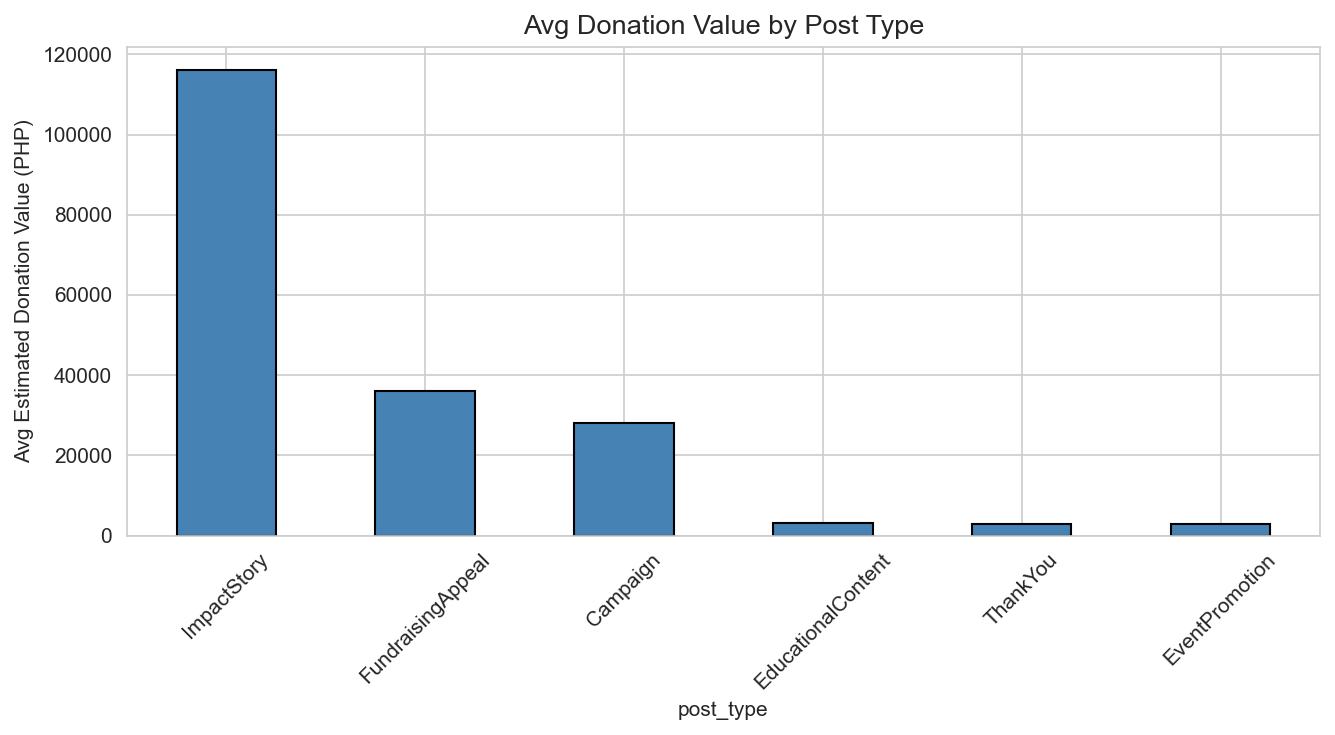

  [ saved ] avg_value_by_post_type.png


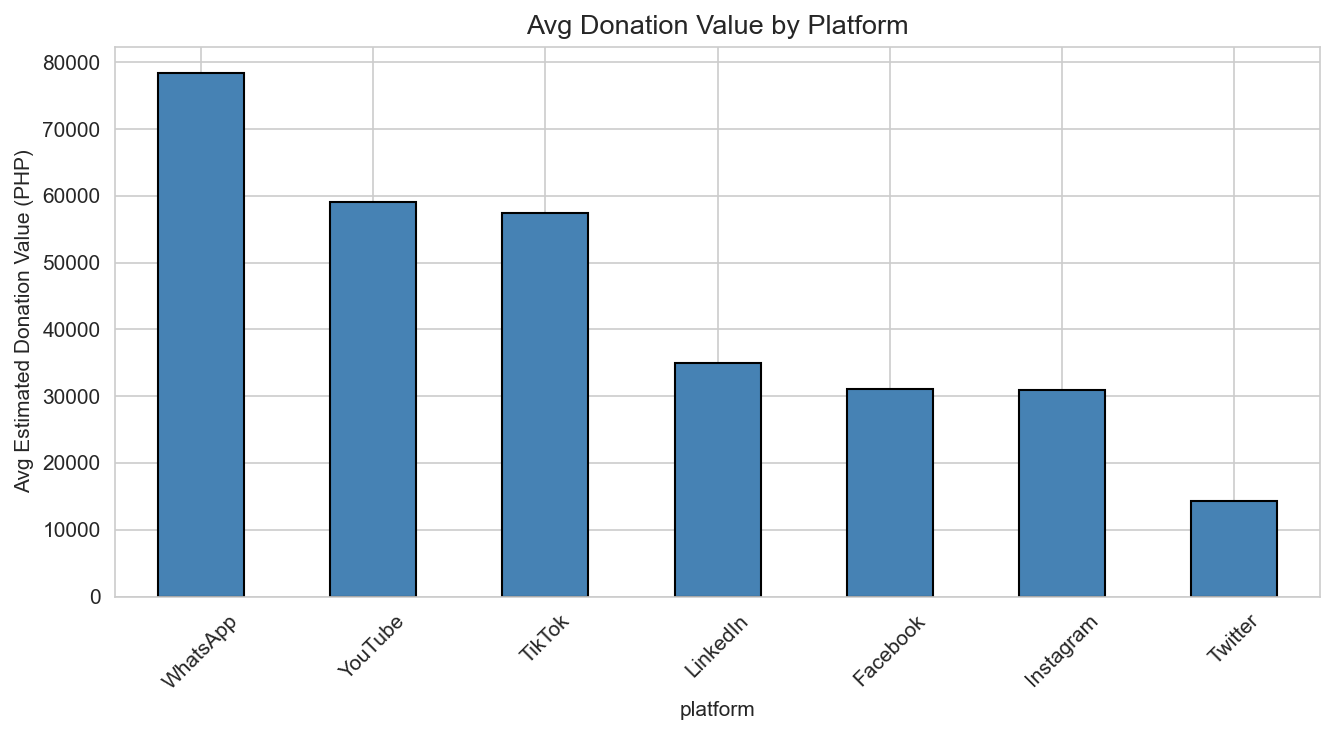

  [ saved ] avg_value_by_platform.png


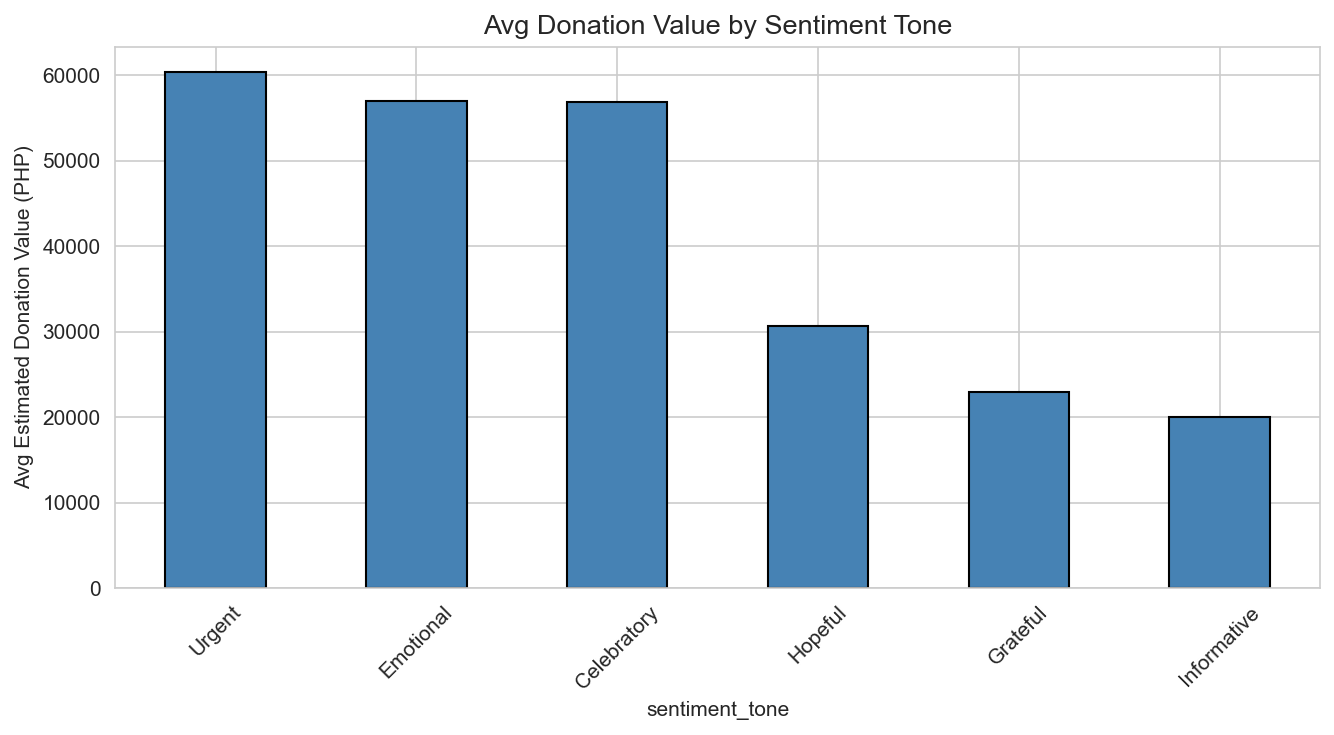

  [ saved ] avg_value_by_sentiment.png


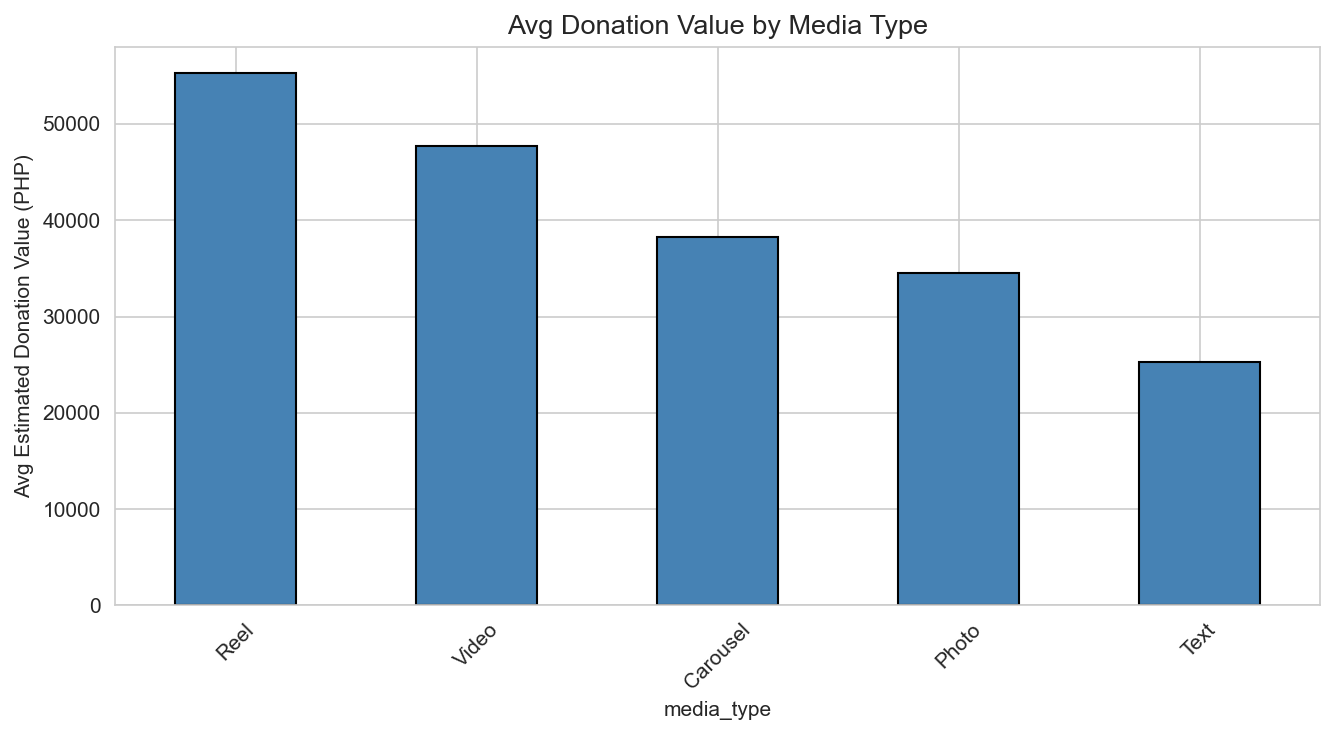

  [ saved ] avg_value_by_media_type.png


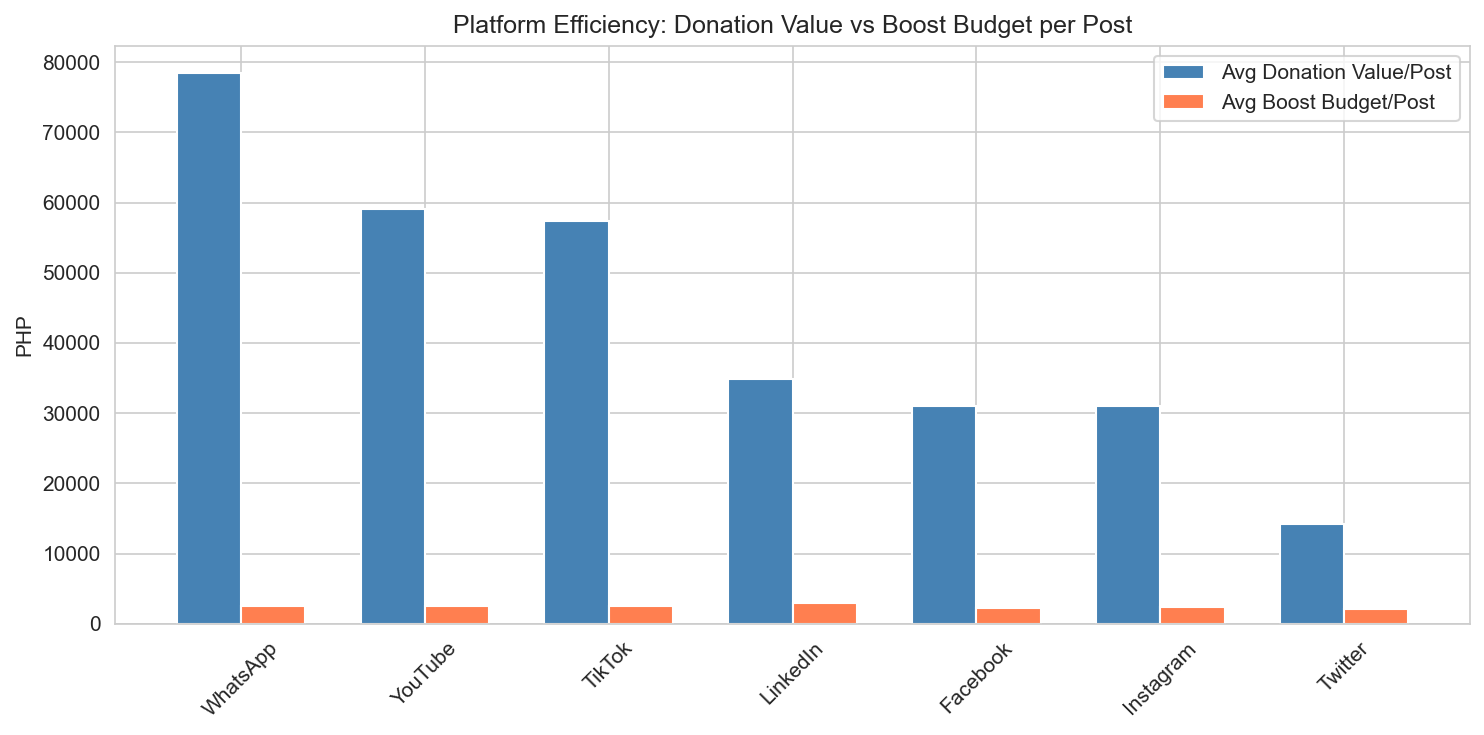

  [ saved ] platform_efficiency.png


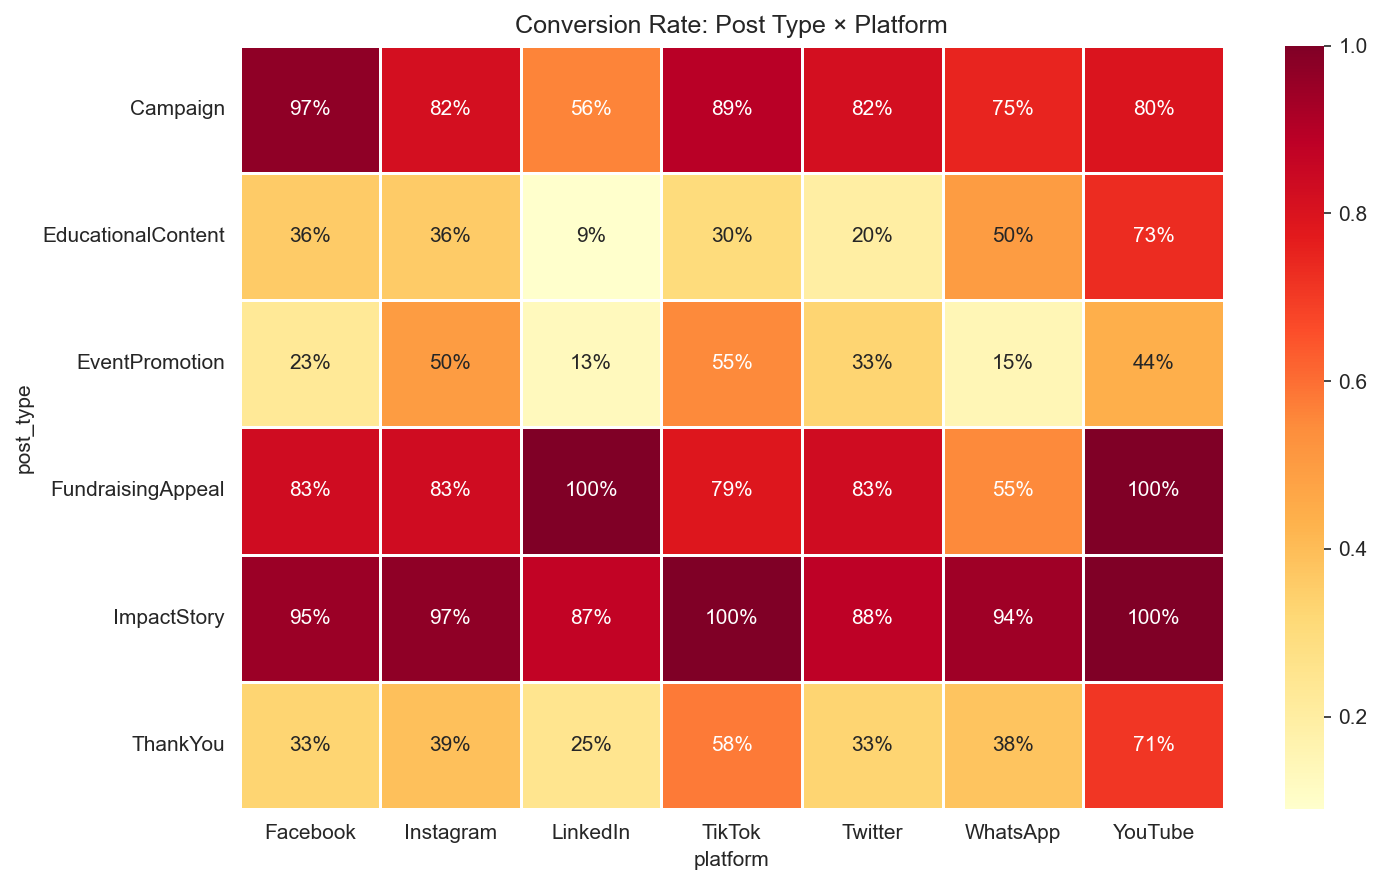

  [ saved ] conversion_heatmap.png


In [33]:
expected_figures = [
    'univariate_eda.png',
    'bivariate_eda.png',
    'correlation_heatmap.png',
    'ols_linearity_lowess.png',
    'ols_qq_plot.png',
    'ols_residuals_fitted.png',
    'logistic_odds_ratios.png',
    'ols_coefficients.png',
    'engagement_donation_gap.png'
]

print(f"Figures directory: {CONFIG['figures_dir']}")
print(f"Resolution: {CONFIG['dpi']} DPI\n")

for fig_name in expected_figures:
    path = os.path.join(CONFIG['figures_dir'], fig_name)
    status = "exists" if os.path.exists(path) else "MISSING"
    print(f"  [{status:>7}] {fig_name}")

# --- Standalone bar charts required by context document ---
categories = [
    ('post_type', 'Avg Donation Value by Post Type',
     'avg_value_by_post_type.png'),
    ('platform', 'Avg Donation Value by Platform',
     'avg_value_by_platform.png'),
    ('sentiment_tone', 'Avg Donation Value by Sentiment Tone',
     'avg_value_by_sentiment.png'),
    ('media_type', 'Avg Donation Value by Media Type',
     'avg_value_by_media_type.png'),
]

for col, title, fname in categories:
    fig, ax = plt.subplots(figsize=(9, 5))
    (df_raw_master.groupby(col)['estimated_donation_value_php']
     .mean().sort_values(ascending=False)
     .plot(kind='bar', ax=ax, color='steelblue', edgecolor='black'))
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Avg Estimated Donation Value (PHP)')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(CONFIG['figures_dir'] + fname,
                dpi=CONFIG['dpi'], bbox_inches='tight')
    plt.show()
    print(f"  [ saved ] {fname}")

# Platform efficiency chart (value/post vs budget/post)
fig, ax = plt.subplots(figsize=(10, 5))
eff_plot = df_raw_master.groupby('platform').agg(
    avg_value=('estimated_donation_value_php', 'mean'),
    avg_budget=('boost_budget_php', 'mean')
).sort_values('avg_value', ascending=False)
x = np.arange(len(eff_plot))
w = 0.35
ax.bar(x - w/2, eff_plot['avg_value'], w, label='Avg Donation Value/Post',
       color='steelblue')
ax.bar(x + w/2, eff_plot['avg_budget'], w, label='Avg Boost Budget/Post',
       color='coral')
ax.set_xticks(x)
ax.set_xticklabels(eff_plot.index, rotation=45)
ax.set_ylabel('PHP')
ax.set_title('Platform Efficiency: Donation Value vs Boost Budget per Post')
ax.legend()
plt.tight_layout()
plt.savefig(CONFIG['figures_dir'] + 'platform_efficiency.png',
            dpi=CONFIG['dpi'], bbox_inches='tight')
plt.show()
print("  [ saved ] platform_efficiency.png")

# Conversion-rate heatmap
pivot = df_raw_master.pivot_table(
    index='post_type', columns='platform',
    values='has_any_donations', aggfunc='mean'
).round(2)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title('Conversion Rate: Post Type × Platform')
plt.tight_layout()
plt.savefig(CONFIG['figures_dir'] + 'conversion_heatmap.png',
            dpi=CONFIG['dpi'], bbox_inches='tight')
plt.show()
print("  [ saved ] conversion_heatmap.png")

---
## Section 34 — Stakeholder Briefing

A comprehensive, dynamically generated executive briefing for the social
media manager, fundraising director, and executive leadership.

In [34]:
top_conv_type = (df_raw_master.groupby('post_type')['has_any_donations']
                 .mean().idxmax())
top_conv_plat = (df_raw_master.groupby('platform')['has_any_donations']
                 .mean().idxmax())
top_val_plat = (df_raw_master.groupby('platform')
                ['estimated_donation_value_php'].mean().idxmax())

briefing = f"""
{'='*60}
  SOCIAL MEDIA ROI & CONTENT STRATEGY ANALYSIS
  Stakeholder Briefing
{'='*60}

1. EXECUTIVE SUMMARY
   -  Analyzed {len(df_raw_master):,} social media posts across
      {df_raw_master['platform'].nunique()} platforms.
   -  Overall conversion rate (posts generating any donation):
      {df_raw_master['has_any_donations'].mean()*100:.1f}%
   -  Converting posts: {(df_raw_master['has_any_donations']==1).sum():,}

2. MODEL PERFORMANCE
   -  Logistic (conversion):  Pseudo R² = {logit_result.prsquared:.3f}
   -  OLS (donation value):   Adj R²    = {ols_result.rsquared_adj:.3f}

3. KEY FINDINGS
   -  Highest-converting post type: {top_conv_type}
   -  Highest-converting platform:  {top_conv_plat}
   -  Highest avg donation value:   {top_val_plat}

4. RECOMMENDATIONS
   -  Focus donation-targeted content on {top_conv_plat} + {top_conv_type}
   -  Use model coefficients to guide tone, CTA, and timing decisions
   -  Design A/B tests based on these associational findings

5. CAVEATS
   -  All findings are associational — not causal
   -  Boost selection bias exists
   -  Engagement still matters for long-term audience building

Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
"""

print(briefing)

with open(CONFIG['json_dir'] + 'STAKEHOLDER_BRIEFING.txt', 'w') as f:
    f.write(briefing)
print("Saved: STAKEHOLDER_BRIEFING.txt")


  SOCIAL MEDIA ROI & CONTENT STRATEGY ANALYSIS
  Stakeholder Briefing

1. EXECUTIVE SUMMARY
   -  Analyzed 812 social media posts across
      7 platforms.
   -  Overall conversion rate (posts generating any donation):
      64.3%
   -  Converting posts: 522

2. MODEL PERFORMANCE
   -  Logistic (conversion):  Pseudo R² = 0.921
   -  OLS (donation value):   Adj R²    = 0.777

3. KEY FINDINGS
   -  Highest-converting post type: ImpactStory
   -  Highest-converting platform:  YouTube
   -  Highest avg donation value:   WhatsApp

4. RECOMMENDATIONS
   -  Focus donation-targeted content on YouTube + ImpactStory
   -  Use model coefficients to guide tone, CTA, and timing decisions
   -  Design A/B tests based on these associational findings

5. CAVEATS
   -  All findings are associational — not causal
   -  Boost selection bias exists
   -  Engagement still matters for long-term audience building

Generated: 2026-04-08 16:29:47

Saved: STAKEHOLDER_BRIEFING.txt


In [35]:
import json as _json_export
from pathlib import Path
import joblib

# ══════════════════════════════════════════════════════════════════════
# EXPORT model3.sav + model3.meta.json  (Social Media Explanatory Pipeline)
# ══════════════════════════════════════════════════════════════════════
# This notebook produced TWO explanatory models (statsmodels, not sklearn):
#   1. logit_result  — Logistic regression on has_any_donations  (Part A hurdle)
#   2. ols_result    — OLS regression on log_estimated_donation_value_php (Part B hurdle)
# We save logit_result as the primary model artifact (the core
# question is which post characteristics are associated with generating donations).

out_dir = Path.cwd()
model_path = out_dir / "model3.sav"
meta_path  = out_dir / "model3.meta.json"

joblib.dump(logit_result, model_path)

pseudo_r2 = logit_result.prsquared

meta = {
    "pipeline":            "SocialMediaExplanatory",
    "model_type":          "Logistic Regression (statsmodels, hurdle Part A)",
    "target_variable":     "has_any_donations",
    "pseudo_r_squared":    float(pseudo_r2),
    "log_likelihood":      float(logit_result.llf),
    "n_obs":               int(logit_result.nobs),
    "n_features":          len(feature_cols),
    "aic":                 float(logit_result.aic),
    "bic":                 float(logit_result.bic),
    "features":            feature_cols,
    "saved_model":         str(model_path.name),
    "secondary_model":     "ols_result (log_estimated_donation_value_php, hurdle Part B)",
    "secondary_adj_r2":    float(ols_result.rsquared_adj),
    "secondary_aic":       float(ols_result.aic),
    "secondary_target":    "log_estimated_donation_value_php",
    "ethical_note":        "Explanatory only — associations, not predictions. Do NOT use for individual post scoring.",
}

meta_path.write_text(_json_export.dumps(meta, indent=2), encoding="utf-8")

print(f"Saved Logit model → {model_path}  ({model_path.stat().st_size / 1024:.1f} KB)")
print(f"Saved metadata    → {meta_path}  ({meta_path.stat().st_size / 1024:.1f} KB)")


Saved Logit model → C:\Users\camjw\OneDrive\Desktop\BYU\9. Winter 2026\Intex2\Intex2\INTEX2\ml-pipelines\pipeline\model3.sav  (1593.3 KB)
Saved metadata    → C:\Users\camjw\OneDrive\Desktop\BYU\9. Winter 2026\Intex2\Intex2\INTEX2\ml-pipelines\pipeline\model3.meta.json  (3.8 KB)


In [36]:
# ── Domain summary export (admin-friendly plain English) ─────────────────────
import json as _j
from pathlib import Path

_out_dir = Path("../output/social-media-explanatory")
_out_dir.mkdir(parents=True, exist_ok=True)

try:
    _n_posts = int(len(df_raw_master))
    _n_conv = int((df_raw_master["has_any_donations"] == 1).sum())
    _conv_rate = round(_n_conv / _n_posts * 100, 1)
except:
    _n_posts = _n_conv = _conv_rate = None

# Top 2 factors: platform and post type with highest donation conversion
_top_factors = []
try:
    _top_plat = str(df_raw_master.groupby("platform")["has_any_donations"].mean().idxmax())
    _top_factors.append(f"{_top_plat} posts")
except:
    pass
try:
    _top_type = str(df_raw_master.groupby("post_type")["has_any_donations"].mean().idxmax())
    _top_factors.append(f"{_top_type} content")
except:
    pass

_parts = []
if _n_posts:
    if _conv_rate is not None:
        _parts.append(f"{_n_posts:,} social media posts were analyzed; {_conv_rate}% led to a donation.")
    else:
        _parts.append(f"{_n_posts:,} social media posts were analyzed.")
if len(_top_factors) >= 2:
    _parts.append(f"The two strongest drivers of donation conversion are {_top_factors[0]} and {_top_factors[1]}.")
elif len(_top_factors) == 1:
    _parts.append(f"The strongest driver of donation conversion is {_top_factors[0]}.")
_parts.append("The prediction table below scores each post by its likelihood of generating a donation, helping your team focus on the content that drives the most impact.")

_summary = " ".join(_parts) if _parts else "Social media impact analysis complete. The prediction table scores posts by their likelihood of generating donations."

(_out_dir / "domain_summary.json").write_text(
    _j.dumps({"summary": _summary}, indent=2, ensure_ascii=False), encoding="utf-8"
)
print(f"domain_summary.json written: {_summary}")


domain_summary.json written: 812 social media posts were analyzed; 64.3% led to a donation. The two strongest drivers of donation conversion are YouTube posts and ImpactStory content. The prediction table below scores each post by its likelihood of generating a donation, helping your team focus on the content that drives the most impact.
